# Research Press Intensity Fixed Threshold Model

This notebook is a copied threshold-analysis variant of the research press intensity model. It keeps the same research-paper-based `press_intensity` computation, but changes the threshold search strategy.

The target is `press_success_any`:

- `1` = successful pressing episode
- `0` = unsuccessful pressing episode

The predictor is newly computed `press_intensity`, not `press_intensity_score` from any other notebook. The modelling rule is intentionally interpretable:

`pred_success = 1 if press_intensity >= threshold else 0`

The original copied approach searched many data-adaptive thresholds from the training distribution. This notebook instead tests a fixed threshold grid from `0.05` to `0.95` in steps of `0.05`, making the threshold analysis easier to explain and compare.

In [4]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from kloppy import secondspectrum
except Exception as exc:
    secondspectrum = None
    KLOPPY_IMPORT_ERROR = exc
else:
    KLOPPY_IMPORT_ERROR = None

PROJECT_ROOT = Path.cwd()
LOCAL_NOTEBOOK_DIR = PROJECT_ROOT / "Superliga_2024_2025_selected_TEST_DATA_3MATCHES"

RAW_MATCHFEEDS_ROOT = Path("/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds")
FULL_SEASON_FEATURE_ROOT = RAW_MATCHFEEDS_ROOT / "_generated_pressing_outputs"
FINAL_WANDB_ROOT = Path(
    "/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS/MASTER_SDU_2026/"
    "SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT/W&B"
)

DATA_ROOT = RAW_MATCHFEEDS_ROOT
EPISODE_SOURCE_PATH = FULL_SEASON_FEATURE_ROOT / "full_season_press_features_settled_high_press.parquet"
SPLIT_ASSIGNMENTS_PATH = FINAL_WANDB_ROOT / "full_season_press_model_split_assignments.parquet"

OUTPUT_DIR = FINAL_WANDB_ROOT / "research_press_intensity_model_outputs_full_season"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIXED_THRESHOLD_OUTPUT_DIR = FINAL_WANDB_ROOT / "research_press_intensity_fixed_threshold_outputs_full_season"
FIXED_THRESHOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESEARCH_INTENSITY_TABLE_PATH = OUTPUT_DIR / "research_press_intensity_episode_table_full_season.parquet"
THRESHOLD_TRAIN_RESULTS_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_train_results_full_season.csv"
THRESHOLD_VALIDATION_RESULTS_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_validation_results_full_season.csv"
THRESHOLD_MANIFEST_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_manifest_full_season.json"
TEST_METRICS_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_test_metrics_full_season.json"
TEST_PREDICTIONS_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_test_predictions_full_season.csv"

# Research-paper pressing intensity parameters.
T_WINDOW = 1.5
SIGMA = 0.45
TAU_R = 0.7
V_MAX = 8.0
V_ACTIVE = 2.0
SPRINT_THRESHOLD = 5.0
EPS = 1e-9
EARLY_PRESS_WINDOW = (0.0, 1.0)

RECOMPUTE_RESEARCH_PRESS_INTENSITY = True
RUN_OPTIONAL_LOGISTIC_REGRESSION = True

for required_path in [DATA_ROOT, EPISODE_SOURCE_PATH, SPLIT_ASSIGNMENTS_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Required full-season path is missing: {required_path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw 192-match feed root: {DATA_ROOT}")
print(f"Full-season episode source: {EPISODE_SOURCE_PATH}")
print(f"Full-season split assignments: {SPLIT_ASSIGNMENTS_PATH}")
print(f"Research intensity cache dir: {OUTPUT_DIR}")
print(f"Fixed threshold output dir: {FIXED_THRESHOLD_OUTPUT_DIR}")
print("Research press_intensity parameters:")
print({
    "T_WINDOW": T_WINDOW,
    "SIGMA": SIGMA,
    "TAU_R": TAU_R,
    "V_MAX": V_MAX,
    "V_ACTIVE": V_ACTIVE,
    "SPRINT_THRESHOLD": SPRINT_THRESHOLD,
})
if secondspectrum is None:
    print(f"Kloppy import warning: {KLOPPY_IMPORT_ERROR}")

Project root: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES
Raw 192-match feed root: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds
Full-season episode source: /Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds/_generated_pressing_outputs/full_season_press_features_settled_high_press.parquet
Full-season split assignments: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS/MASTER_SDU_2026/SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT/W&B/full_season_press_model_split_assignments.parquet
Research intensity cache dir: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS/MASTER_SDU_2026/SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT/W&B/research_press_intensity_model_outputs_full_season
Fixed threshold output dir: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS/MASTER_SDU_2026/SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT/W&B/research_press_intensity_fixed_threshold_outputs_full_season
Research pr

## Method Definition

For each active defender-target pair, the notebook computes time-to-intercept as:

`T_i,j(t) = tau_r + tau_i,j(t) + tau_beta(t)`

That value is transformed into an interception probability using a logistic function, then defender probabilities are combined into total pressure:

`P_j = 1 - prod_i(1 - p_i,j)`

A defender contributes only when speed is at least `V_ACTIVE = 2.0 m/s`. In this implementation the ball location is used as the target because it is consistently available in the tracking data.

In [5]:
def load_episode_source() -> pd.DataFrame:
    if not EPISODE_SOURCE_PATH.exists():
        raise FileNotFoundError(f"Missing episode source: {EPISODE_SOURCE_PATH}")

    df = pd.read_parquet(EPISODE_SOURCE_PATH).reset_index(drop=True)

    # This notebook deliberately ignores intensity variables from other notebooks.
    ignored_intensity_cols = [c for c in df.columns if c == "press_intensity_score"]
    if ignored_intensity_cols:
        print(f"Ignoring old intensity columns: {ignored_intensity_cols}")
        df = df.drop(columns=ignored_intensity_cols)

    required_cols = ["match_name", "period", "gc_start", "team_side", "press_success_any"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Episode source is missing required columns: {missing}")

    if "episode_id" not in df.columns:
        df = df.copy()
        df.insert(0, "episode_id", np.arange(len(df), dtype=int))

    return df


def load_split_assignments() -> pd.DataFrame:
    if not SPLIT_ASSIGNMENTS_PATH.exists():
        raise FileNotFoundError(f"Missing split assignments: {SPLIT_ASSIGNMENTS_PATH}")
    splits = pd.read_parquet(SPLIT_ASSIGNMENTS_PATH).copy()
    required = {"match_name", "split"}
    missing = sorted(required.difference(splits.columns))
    if missing:
        raise ValueError(f"Split assignments are missing required columns: {missing}")
    return splits


episodes_base = load_episode_source()
split_assignments = load_split_assignments()

split_by_match = split_assignments.groupby("match_name")["split"].nunique()
bad_matches = split_by_match[split_by_match > 1]
if not bad_matches.empty:
    raise RuntimeError(f"Split leakage inside split assignment file: {bad_matches.to_dict()}")

match_to_split = split_assignments.drop_duplicates("match_name").set_index("match_name")["split"]
episodes_base["split"] = episodes_base["match_name"].map(match_to_split)

print(f"Loaded settled high-press episodes: {len(episodes_base):,}")
print(f"Matches: {episodes_base['match_name'].nunique():,}")
print(episodes_base["split"].value_counts(dropna=False).to_string())
display(episodes_base[[c for c in ["episode_id", "match_name", "period", "gc_start", "team_side", "press_success_any", "split"] if c in episodes_base.columns]].head())

Ignoring old intensity columns: ['press_intensity_score']
Loaded settled high-press episodes: 6,851
Matches: 192
split
train         4348
test          1432
validation    1071


,episode_id,match_name,period,gc_start,team_side,press_success_any,split
0,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,134.4,away,1,validation
1,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,147.6,away,1,validation
2,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,250.2,away,0,validation
3,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,661.8,away,0,validation
4,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,670.2,away,1,validation


In [6]:
def find_match_dir(match_name: str) -> Path:
    path = DATA_ROOT / str(match_name)
    if path.exists():
        return path
    candidates = [p for p in DATA_ROOT.iterdir() if p.is_dir() and str(match_name) in p.name]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError(f"Could not locate match folder for: {match_name}")


def load_tracking_kloppy(match_dir: Path):
    if secondspectrum is None:
        raise ImportError("kloppy is required to compute research press_intensity from raw tracking.") from KLOPPY_IMPORT_ERROR
    data_files = [f for f in match_dir.glob("*_SecondSpectrum_Data.json*") if f.suffix in (".json", ".jsonl")]
    if not data_files:
        raise FileNotFoundError(f"No SecondSpectrum data file found in {match_dir}")
    meta_xml = list(match_dir.glob("*_SecondSpectrum_Metadata.xml"))[0]
    meta_json = list(match_dir.glob("*_SecondSpectrum_Metadata.json"))[0]
    return secondspectrum.load(
        raw_data=str(data_files[0]),
        meta_data=str(meta_xml),
        additional_meta_data=str(meta_json),
        coordinates="secondspectrum",
    )


def kloppy_tracking_to_frame_table(dataset) -> pd.DataFrame:
    home_team = dataset.metadata.teams[0]
    away_team = dataset.metadata.teams[1]
    rows = []

    for frame_record in dataset.records:
        period = frame_record.period.id if frame_record.period else 1
        game_clock = frame_record.timestamp.total_seconds() if frame_record.timestamp else 0.0

        if frame_record.ball_coordinates:
            ball_x = frame_record.ball_coordinates.x
            ball_y = frame_record.ball_coordinates.y
            ball_z = getattr(frame_record.ball_coordinates, "z", 0.0) or 0.0
        else:
            ball_x, ball_y, ball_z = np.nan, np.nan, np.nan

        home_players = []
        away_players = []
        for player, coords in frame_record.players_coordinates.items():
            if coords is None:
                continue
            player_data = frame_record.players_data.get(player)
            speed = getattr(coords, "speed", None) or getattr(player_data, "speed", 0.0) or 0.0
            player_row = {
                "playerId": player.player_id,
                "xy": np.asarray([float(coords.x), float(coords.y)], dtype=float),
                "speed": float(speed),
            }
            if player.team == home_team:
                home_players.append(player_row)
            elif player.team == away_team:
                away_players.append(player_row)

        rows.append({
            "period": int(period),
            "gameClock": float(game_clock),
            "ball_x": float(ball_x) if pd.notna(ball_x) else np.nan,
            "ball_y": float(ball_y) if pd.notna(ball_y) else np.nan,
            "ball_z": float(ball_z) if pd.notna(ball_z) else np.nan,
            "home_players": home_players,
            "away_players": away_players,
        })

    return pd.DataFrame(rows).sort_values(["period", "gameClock"]).reset_index(drop=True)


def load_match_tracking(match_name: str) -> pd.DataFrame:
    match_dir = find_match_dir(match_name)
    dataset = load_tracking_kloppy(match_dir)
    try:
        tracking = kloppy_tracking_to_frame_table(dataset)
    finally:
        del dataset
    return tracking

In [7]:
def _players_for_side(frame: pd.Series | dict, side: str):
    if side == "home":
        return frame["home_players"]
    if side == "away":
        return frame["away_players"]
    raise ValueError("team_side must be 'home' or 'away'")


def _player_state_by_id(players):
    states = {}
    for player in players or []:
        player_id = player.get("playerId")
        xy = player.get("xy")
        if player_id is None or xy is None:
            continue
        xy = np.asarray(xy, dtype=float)
        if xy.shape[0] < 2 or np.any(pd.isna(xy[:2])):
            continue
        speed = player.get("speed", 0.0)
        states[str(player_id)] = {"xy": xy[:2], "speed": float(speed) if pd.notna(speed) else 0.0}
    return states


def _estimated_velocity(player_id: str, xy: np.ndarray, previous_states: dict, dt: float) -> np.ndarray:
    if previous_states is None or player_id not in previous_states or dt <= 0:
        return np.zeros(2, dtype=float)
    return (np.asarray(xy, dtype=float) - previous_states[player_id]["xy"]) / max(float(dt), 0.04)


def _ball_xy(frame: pd.Series | dict) -> np.ndarray:
    return np.asarray([frame.get("ball_x", np.nan), frame.get("ball_y", np.nan)], dtype=float)


def _ball_velocity(frame: pd.Series | dict, previous_frame: pd.Series | dict | None, dt: float) -> np.ndarray:
    if frame is None or previous_frame is None or dt <= 0:
        return np.zeros(2, dtype=float)
    current_xy = _ball_xy(frame)
    previous_xy = _ball_xy(previous_frame)
    if np.any(pd.isna(current_xy)) or np.any(pd.isna(previous_xy)):
        return np.zeros(2, dtype=float)
    return (current_xy - previous_xy) / max(float(dt), 0.04)


def _angular_penalty(player_velocity: np.ndarray, player_xy: np.ndarray, target_xy: np.ndarray) -> float:
    to_target = np.asarray(target_xy, dtype=float) - np.asarray(player_xy, dtype=float)
    distance = float(np.linalg.norm(to_target))
    speed = float(np.linalg.norm(player_velocity))
    if distance <= EPS or speed <= EPS:
        return 0.0
    alignment = float(np.dot(player_velocity, to_target) / max(speed * distance, EPS))
    return float(max(0.0, -alignment) * TAU_R)


def _time_to_intercept(player_xy: np.ndarray, player_velocity: np.ndarray, target_xy: np.ndarray, target_velocity: np.ndarray) -> float:
    player_future = np.asarray(player_xy, dtype=float) + np.asarray(player_velocity, dtype=float) * TAU_R
    target_future = np.asarray(target_xy, dtype=float) + np.asarray(target_velocity, dtype=float) * TAU_R
    distance_after_reaction = float(np.linalg.norm(target_future - player_future))
    travel_time = distance_after_reaction / max(float(V_MAX), EPS)
    return float(TAU_R + travel_time + _angular_penalty(player_velocity, player_xy, target_xy))


def _intercept_probability(time_to_intercept: float) -> float:
    if pd.isna(time_to_intercept):
        return np.nan
    scale = math.pi / (math.sqrt(3.0) * max(float(SIGMA), EPS))
    z = np.clip(scale * (float(T_WINDOW) - float(time_to_intercept)), -50.0, 50.0)
    return float(1.0 / (1.0 + np.exp(-z)))


def frame_research_press_intensity(frame: pd.Series, previous_frame: pd.Series | None, pressing_side: str) -> dict:
    target_xy = _ball_xy(frame)
    if np.any(pd.isna(target_xy)):
        return {"press_intensity": np.nan, "max_individual_pressure": np.nan, "n_active_pressers": 0, "n_pressers_evaluated": 0}

    frame_gc = float(frame.get("gameClock", np.nan))
    previous_gc = float(previous_frame.get("gameClock", np.nan)) if previous_frame is not None else np.nan
    dt = max(frame_gc - previous_gc, 0.04) if pd.notna(frame_gc) and pd.notna(previous_gc) else 0.04

    current_states = _player_state_by_id(_players_for_side(frame, pressing_side))
    previous_states = _player_state_by_id(_players_for_side(previous_frame, pressing_side)) if previous_frame is not None else {}
    target_velocity = _ball_velocity(frame, previous_frame, dt)

    probabilities = []
    active_count = 0
    for player_id, state in current_states.items():
        player_speed = float(state["speed"])
        if player_speed < V_ACTIVE:
            probabilities.append(0.0)
            continue
        active_count += 1
        player_velocity = _estimated_velocity(player_id, state["xy"], previous_states, dt)
        tti = _time_to_intercept(state["xy"], player_velocity, target_xy, target_velocity)
        probabilities.append(_intercept_probability(tti))

    if not probabilities:
        total_pressure = 0.0
        max_pressure = 0.0
    else:
        probs = np.nan_to_num(np.clip(np.asarray(probabilities, dtype=float), 0.0, 1.0), nan=0.0)
        total_pressure = float(1.0 - np.prod(1.0 - probs))
        max_pressure = float(probs.max())

    return {
        "press_intensity": total_pressure,
        "max_individual_pressure": max_pressure,
        "n_active_pressers": int(active_count),
        "n_pressers_evaluated": int(len(current_states)),
    }

In [8]:
def compute_episode_research_press_intensity(episode: pd.Series, tracking: pd.DataFrame) -> dict:
    period = int(episode["period"])
    start_gc = float(episode["gc_start"])
    rel_start, rel_end = EARLY_PRESS_WINDOW
    t0 = start_gc + rel_start
    t1 = start_gc + rel_end
    pressing_side = str(episode["team_side"])

    period_tracking = tracking[tracking["period"].astype(int).eq(period)].sort_values("gameClock").reset_index(drop=True)
    if period_tracking.empty:
        return {"press_intensity": np.nan, "press_intensity_peak": np.nan, "press_intensity_std": np.nan, "n_intensity_frames": 0}

    window = period_tracking[period_tracking["gameClock"].between(t0, t1)].copy()
    if window.empty:
        return {"press_intensity": np.nan, "press_intensity_peak": np.nan, "press_intensity_std": np.nan, "n_intensity_frames": 0}

    values = []
    max_individual = []
    active_pressers = []
    evaluated_pressers = []

    previous_candidates = period_tracking[period_tracking["gameClock"] < float(window.iloc[0]["gameClock"])]
    previous_frame = previous_candidates.iloc[-1] if not previous_candidates.empty else None

    for _, frame in window.iterrows():
        result = frame_research_press_intensity(frame, previous_frame, pressing_side)
        values.append(result["press_intensity"])
        max_individual.append(result["max_individual_pressure"])
        active_pressers.append(result["n_active_pressers"])
        evaluated_pressers.append(result["n_pressers_evaluated"])
        previous_frame = frame

    values = pd.Series(values, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
    max_individual = pd.Series(max_individual, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()

    return {
        "press_intensity": float(values.mean()) if not values.empty else np.nan,
        "press_intensity_peak": float(values.max()) if not values.empty else np.nan,
        "press_intensity_std": float(values.std(ddof=0)) if len(values) > 1 else 0.0 if len(values) == 1 else np.nan,
        "max_individual_pressure_mean": float(max_individual.mean()) if not max_individual.empty else np.nan,
        "n_active_pressers_mean": float(np.nanmean(active_pressers)) if len(active_pressers) else np.nan,
        "n_pressers_evaluated_mean": float(np.nanmean(evaluated_pressers)) if len(evaluated_pressers) else np.nan,
        "n_intensity_frames": int(len(values)),
    }


def compute_research_press_intensity_table(episodes: pd.DataFrame) -> pd.DataFrame:
    if RESEARCH_INTENSITY_TABLE_PATH.exists() and not RECOMPUTE_RESEARCH_PRESS_INTENSITY:
        print(f"Loading cached research press_intensity table: {RESEARCH_INTENSITY_TABLE_PATH}")
        return pd.read_parquet(RESEARCH_INTENSITY_TABLE_PATH)

    rows = []
    match_names = sorted(episodes["match_name"].dropna().astype(str).unique())
    for idx, match_name in enumerate(match_names, 1):
        match_episodes = episodes[episodes["match_name"].astype(str).eq(match_name)].copy()
        print(f"[{idx}/{len(match_names)}] Computing research press_intensity: {match_name} ({len(match_episodes):,} episodes)")
        tracking = load_match_tracking(match_name)
        for _, episode in match_episodes.iterrows():
            out = compute_episode_research_press_intensity(episode, tracking)
            for key in ["episode_id", "match_name", "period", "gc_start", "team_side", "team_id", "press_success_any", "split"]:
                if key in episode.index:
                    out[key] = episode[key]
            rows.append(out)
        del tracking

    intensity_df = pd.DataFrame(rows)
    metadata = {
        "created_by": "Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb",
        "variable": "press_intensity",
        "ignored_variable": "press_intensity_score",
        "target": "press_success_any",
        "window": {"start": EARLY_PRESS_WINDOW[0], "end": EARLY_PRESS_WINDOW[1]},
        "parameters": {"T_WINDOW": T_WINDOW, "SIGMA": SIGMA, "TAU_R": TAU_R, "V_MAX": V_MAX, "V_ACTIVE": V_ACTIVE},
        "n_rows": int(len(intensity_df)),
        "n_matches": int(intensity_df["match_name"].nunique()) if "match_name" in intensity_df.columns else None,
        "data_scope": "full_season_192_matches",
    }
    intensity_df.attrs["research_press_intensity_metadata"] = metadata
    intensity_df.to_parquet(RESEARCH_INTENSITY_TABLE_PATH, index=False)
    with open(OUTPUT_DIR / "research_press_intensity_computation_metadata.json", "w") as fh:
        json.dump(metadata, fh, indent=2)
    print(f"Saved: {RESEARCH_INTENSITY_TABLE_PATH}")
    return intensity_df


research_intensity_df = compute_research_press_intensity_table(episodes_base)
print(research_intensity_df[["press_intensity", "press_success_any", "split"]].describe(include="all"))
display(research_intensity_df.head())

[1/192] Computing research press_intensity: 2024-07-19 AGF - FC Midtjylland (2442545) (35 episodes)
[2/192] Computing research press_intensity: 2024-07-19 FC Nordsjælland - AaB (2442546) (64 episodes)
[3/192] Computing research press_intensity: 2024-07-21 Silkeborg IF - SønderjyskE (2442547) (22 episodes)
[4/192] Computing research press_intensity: 2024-07-21 Vejle Boldklub - Randers FC (2442548) (27 episodes)
[5/192] Computing research press_intensity: 2024-07-21 Viborg FF - Brøndby IF (2442549) (31 episodes)
[6/192] Computing research press_intensity: 2024-07-22 Lyngby Boldklub - F.C. København (2442550) (35 episodes)
[7/192] Computing research press_intensity: 2024-07-26 SønderjyskE - Lyngby Boldklub (2442551) (32 episodes)
[8/192] Computing research press_intensity: 2024-07-27 FC Nordsjælland - FC Midtjylland (2442552) (59 episodes)
[9/192] Computing research press_intensity: 2024-07-28 AaB - Silkeborg IF (2442554) (44 episodes)
[10/192] Computing research press_intensity: 2024-07-

,press_intensity,press_intensity_peak,press_intensity_std,max_individual_pressure_mean,n_active_pressers_mean,n_pressers_evaluated_mean,n_intensity_frames,episode_id,match_name,period,gc_start,team_side,team_id,press_success_any,split
0,0.930255,0.992085,0.091710,0.815843,4.192308,11.0,26,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,134.4,away,1000,1,validation
1,0.216854,0.614783,0.121241,0.216627,10.000000,11.0,26,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,147.6,away,1000,1,validation
2,0.464721,0.721129,0.177265,0.464490,4.576923,11.0,26,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,250.2,away,1000,0,validation
3,0.819817,0.955517,0.105048,0.796690,10.000000,11.0,26,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,661.8,away,1000,0,validation
4,0.061429,0.200017,0.054435,0.060999,8.769231,11.0,26,2024-07-19 AGF - FC Midtjylland (2442545)__1__...,2024-07-19 AGF - FC Midtjylland (2442545),1,670.2,away,1000,1,validation


In [9]:
def prepare_modelling_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required = ["press_intensity", "press_success_any", "match_name", "split"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required modelling columns: {missing}")

    model_df = df.copy()
    model_df = model_df.replace([np.inf, -np.inf], np.nan)
    model_df = model_df.dropna(subset=["press_intensity", "press_success_any", "match_name", "split"]).reset_index(drop=True)
    model_df["press_success_any"] = model_df["press_success_any"].astype(int)

    outside_range = model_df[~model_df["press_intensity"].between(0.0, 1.0)]
    if len(outside_range) > 0:
        warnings.warn(f"{len(outside_range)} rows have press_intensity outside [0, 1]. They will be clipped for modelling.")
        model_df["press_intensity"] = model_df["press_intensity"].clip(0.0, 1.0)

    splits_by_match = model_df.groupby("match_name")["split"].nunique()
    overlap = splits_by_match[splits_by_match > 1]
    if not overlap.empty:
        raise RuntimeError(f"Match leakage across splits detected: {overlap.to_dict()}")

    expected_splits = {"train", "validation", "test"}
    present_splits = set(model_df["split"].dropna().astype(str).unique())
    missing_splits = expected_splits - present_splits
    if missing_splits:
        raise RuntimeError(f"Missing required splits: {sorted(missing_splits)}")

    return model_df


model_df = prepare_modelling_dataframe(research_intensity_df)

split_summary = model_df.groupby("split").agg(
    rows=("press_success_any", "size"),
    matches=("match_name", "nunique"),
    success_rate=("press_success_any", "mean"),
    mean_press_intensity=("press_intensity", "mean"),
).reset_index()
display(split_summary)

train_df = model_df[model_df["split"].eq("train")].copy()
validation_df = model_df[model_df["split"].eq("validation")].copy()
test_df = model_df[model_df["split"].eq("test")].copy()

print(f"Modelling rows: {len(model_df):,}")
print(f"Train rows: {len(train_df):,} | Validation rows: {len(validation_df):,} | Test rows: {len(test_df):,}")

,split,rows,matches,success_rate,mean_press_intensity
0,test,1432,39,0.472765,0.581731
1,train,4348,122,0.462052,0.585719
2,validation,1071,31,0.458450,0.579301


Modelling rows: 6,851
Train rows: 4,348 | Validation rows: 1,071 | Test rows: 1,432


,count,mean,std,min,25%,50%,75%,max
press_success_any,,,,,,,,
0,2339.0,0.561131,0.255701,0.002565,0.366462,0.595690,0.781539,0.992952
1,2009.0,0.614345,0.251602,0.005663,0.437493,0.680332,0.819608,0.997502


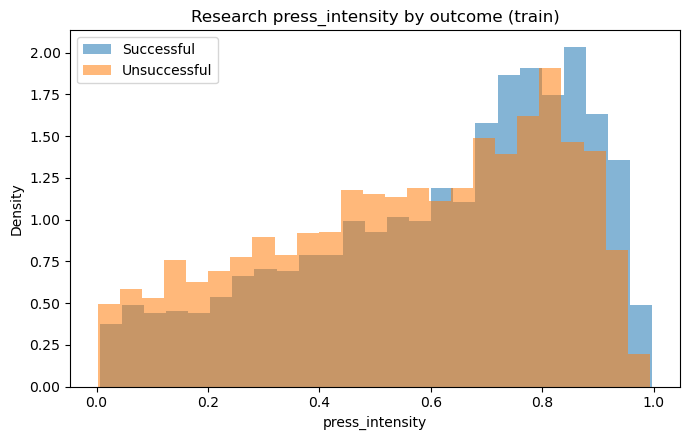

,intensity_decile,n_episodes,mean_press_intensity,success_rate
0,"(0.0015699999999999998, 0.196]",435,0.102902,0.383908
1,"(0.196, 0.334]",435,0.269922,0.413793
2,"(0.334, 0.454]",435,0.397103,0.425287
3,"(0.454, 0.546]",434,0.498744,0.414747
4,"(0.546, 0.636]",435,0.591124,0.434483
5,"(0.636, 0.709]",435,0.676759,0.464368
6,"(0.709, 0.772]",434,0.741222,0.511521
7,"(0.772, 0.828]",435,0.800059,0.462069
8,"(0.828, 0.884]",435,0.856057,0.528736
9,"(0.884, 0.998]",435,0.923454,0.581609


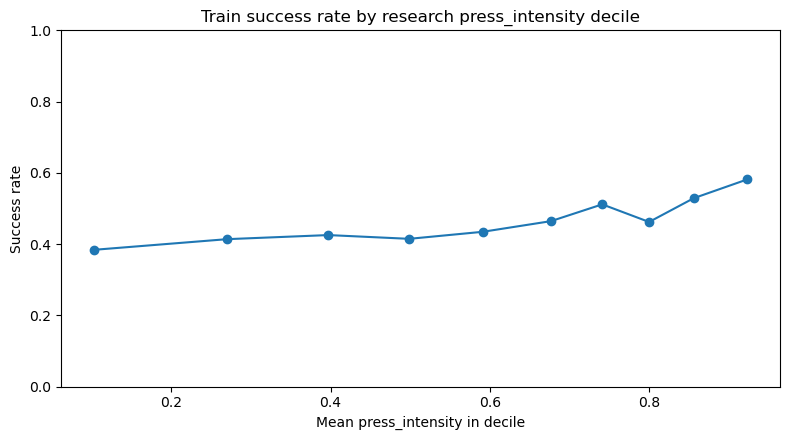

In [10]:
PLOT_DISTRIBUTION_PATH = OUTPUT_DIR / "research_press_intensity_distribution_fullSeason_by_success.png"
PLOT_BIN_SUCCESS_PATH = OUTPUT_DIR / "research_press_intensity_success_fullSeason_by_decile.png"

train_stats = train_df.groupby("press_success_any")["press_intensity"].describe()
display(train_stats)

plot_train = train_df.copy()
plot_train["success_label"] = plot_train["press_success_any"].map({0: "Unsuccessful", 1: "Successful"})

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, group in plot_train.groupby("success_label"):
    ax.hist(group["press_intensity"], bins=25, alpha=0.55, label=label, density=True)
ax.set_title("Research press_intensity by outcome (train)")
ax.set_xlabel("press_intensity")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DISTRIBUTION_PATH, dpi=220, bbox_inches="tight")
plt.show()

train_bins = train_df.copy()
train_bins["intensity_decile"] = pd.qcut(train_bins["press_intensity"], q=10, duplicates="drop")
decile_summary = train_bins.groupby("intensity_decile", observed=False).agg(
    n_episodes=("press_success_any", "size"),
    mean_press_intensity=("press_intensity", "mean"),
    success_rate=("press_success_any", "mean"),
).reset_index()
decile_summary["intensity_decile"] = decile_summary["intensity_decile"].astype(str)
display(decile_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decile_summary["mean_press_intensity"], decile_summary["success_rate"], marker="o")
ax.set_ylim(0, 1)
ax.set_title("Train success rate by research press_intensity decile")
ax.set_xlabel("Mean press_intensity in decile")
ax.set_ylabel("Success rate")
fig.tight_layout()
fig.savefig(PLOT_BIN_SUCCESS_PATH, dpi=220, bbox_inches="tight")
plt.show()

,intensity_quartile,n_episodes,mean_press_intensity,success_rate
0,Q1,1087,0.222600,0.402944
1,Q2,1087,0.521202,0.425943
2,Q3,1087,0.724385,0.494020
3,Q4,1087,0.874689,0.525299


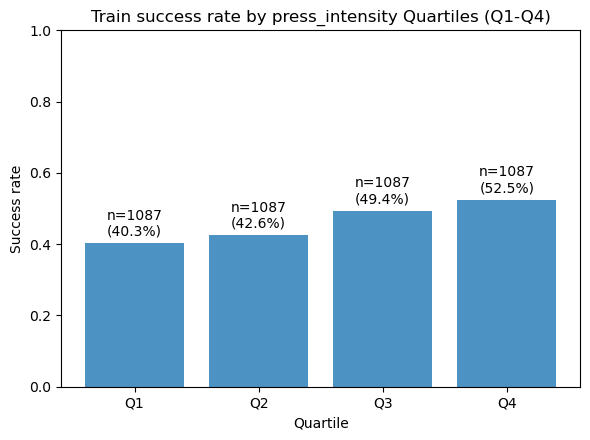

In [11]:
PLOT_QUARTILE_SUCCESS_PATH = OUTPUT_DIR / "research_press_intensity_success_fullSeason_by_quartile.png"

train_quartiles = train_df.copy()
train_quartiles["intensity_quartile"] = pd.qcut(train_quartiles["press_intensity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
quartile_summary = train_quartiles.groupby("intensity_quartile", observed=False).agg(
    n_episodes=("press_success_any", "size"),
    mean_press_intensity=("press_intensity", "mean"),
    success_rate=("press_success_any", "mean"),
).reset_index()
display(quartile_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(quartile_summary["intensity_quartile"], quartile_summary["success_rate"], color="#1f77b4", alpha=0.8)
ax.set_ylim(0, 1)
ax.set_title("Train success rate by press_intensity Quartiles (Q1-Q4)")
ax.set_xlabel("Quartile")
ax.set_ylabel("Success rate")
for idx, row in quartile_summary.iterrows():
    label_height = row["success_rate"] + 0.02 if pd.notna(row["success_rate"]) else 0.02
    ax.text(idx, label_height, f"n={int(row['n_episodes'])}\n({row['success_rate']*100:.1f}%)", ha="center")
fig.tight_layout()
fig.savefig(PLOT_QUARTILE_SUCCESS_PATH, dpi=220, bbox_inches="tight")
plt.show()


## Fixed Threshold Approach

The copied notebook originally used an adaptive threshold grid. That old approach cleaned the training `press_intensity` values, calculated the 1st to 99th percentiles of the training distribution, and added exact unique training values when the number of unique scores was small. The final threshold was then selected by validation F1.

This notebook uses a different approach. It tests fixed, interpretable threshold values from `0.05` to `0.95` in steps of `0.05`:

`0.05, 0.10, 0.15, ..., 0.95`

For every threshold, the prediction rule is:

`press_success_pred = 1 if press_intensity >= threshold else 0`

This makes the analysis easier to explain because each tested threshold is a predefined press-intensity level rather than a value derived from the training distribution.

In [12]:
def threshold_metrics(y_true, scores, threshold: float) -> dict:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = (scores >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "tpr": float(recall_score(y_true, y_pred, zero_division=0)),
        "fpr": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "n": int(len(y_true)),
    }


def make_fixed_percent_threshold_grid() -> np.ndarray:
    return np.round(np.arange(5, 100, 5, dtype=float) / 100.0, 2)


def scan_thresholds(df: pd.DataFrame, thresholds: np.ndarray) -> pd.DataFrame:
    y_true = df["press_success_any"].astype(int).to_numpy()
    scores = df["press_intensity"].astype(float).to_numpy()
    return pd.DataFrame([threshold_metrics(y_true, scores, threshold) for threshold in thresholds])


candidate_thresholds = make_fixed_percent_threshold_grid()
train_threshold_results = scan_thresholds(train_df, candidate_thresholds)
validation_threshold_results = scan_thresholds(validation_df, candidate_thresholds)

train_threshold_results.to_csv(THRESHOLD_TRAIN_RESULTS_PATH, index=False)
validation_threshold_results.to_csv(THRESHOLD_VALIDATION_RESULTS_PATH, index=False)

print(
    f"Fixed candidate thresholds tested: {candidate_thresholds[0]:.2f} to "
    f"{candidate_thresholds[-1]:.2f} in steps of 0.05 ({len(candidate_thresholds):,} thresholds)"
)
display(pd.DataFrame({"threshold": candidate_thresholds, "threshold_percent": (candidate_thresholds * 100).astype(int)}))
display(validation_threshold_results.sort_values(["f1", "balanced_accuracy"], ascending=[False, False]).head(10))

Fixed candidate thresholds tested: 0.05 to 0.95 in steps of 0.05 (19 thresholds)


,threshold,threshold_percent
0,0.05,5
1,0.10,10
2,0.15,15
3,0.20,20
4,0.25,25
5,0.30,30
6,0.35,35
7,0.40,40
8,0.45,45
9,0.50,50


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,fp,tn,fn,n
1,0.10,0.485528,0.469758,0.949084,0.093103,0.628456,0.521093,0.949084,0.906897,466,526,54,25,1071
0,0.05,0.470588,0.462963,0.967413,0.050000,0.626236,0.508707,0.967413,0.950000,475,551,29,16,1071
2,0.15,0.488329,0.470466,0.924644,0.118966,0.623626,0.521805,0.924644,0.881034,454,511,69,37,1071
3,0.20,0.494865,0.473291,0.902240,0.150000,0.620883,0.526120,0.902240,0.850000,443,493,87,48,1071
4,0.25,0.497666,0.474261,0.881874,0.172414,0.616809,0.527144,0.881874,0.827586,433,480,100,58,1071
5,0.30,0.505135,0.477816,0.855397,0.208621,0.613139,0.532009,0.855397,0.791379,420,459,121,71,1071
6,0.35,0.501401,0.474676,0.820774,0.231034,0.601493,0.525904,0.820774,0.768966,403,446,134,88,1071
7,0.40,0.498599,0.471393,0.771894,0.267241,0.585328,0.519568,0.771894,0.732759,379,425,155,112,1071
8,0.45,0.498599,0.469333,0.716904,0.313793,0.567284,0.515349,0.716904,0.686207,352,398,182,139,1071
9,0.50,0.506069,0.472464,0.663951,0.372414,0.552075,0.518182,0.663951,0.627586,326,364,216,165,1071


In [14]:
def select_final_threshold(validation_results: pd.DataFrame) -> tuple[float, str, pd.Series]:
    selected = validation_results.sort_values(["f1", "balanced_accuracy", "threshold"], ascending=[False, False, True]).iloc[0]
    return float(selected["threshold"]), "max_validation_f1_on_fixed_0_05_grid", selected


def alternative_thresholds(validation_results: pd.DataFrame) -> dict:
    alternatives = {}
    youden = validation_results.assign(youden=validation_results["tpr"] - validation_results["fpr"])
    alternatives["youden"] = youden.sort_values(["youden", "f1"], ascending=[False, False]).iloc[0].to_dict()

    precision_constrained = validation_results[validation_results["precision"] >= 0.70]
    if not precision_constrained.empty:
        alternatives["precision_at_least_0_70"] = precision_constrained.sort_values(["recall", "f1"], ascending=[False, False]).iloc[0].to_dict()

    recall_constrained = validation_results[validation_results["recall"] >= 0.70]
    if not recall_constrained.empty:
        alternatives["recall_at_least_0_70"] = recall_constrained.sort_values(["precision", "f1"], ascending=[False, False]).iloc[0].to_dict()

    top_quartile_threshold = float(train_df["press_intensity"].quantile(0.75))
    alternatives["train_top_quartile"] = threshold_metrics(
        validation_df["press_success_any"],
        validation_df["press_intensity"],
        top_quartile_threshold,
    )
    return alternatives


final_threshold, threshold_selection_rule, validation_selected_row = select_final_threshold(validation_threshold_results)
train_selected_row = train_threshold_results.iloc[(train_threshold_results["threshold"] - final_threshold).abs().argmin()]
threshold_alternatives = alternative_thresholds(validation_threshold_results)

threshold_manifest = {
    "model_name": "research_press_intensity_fixed_threshold_binary_success",
    "predictor": "press_intensity",
    "ignored_predictor": "press_intensity_score",
    "target": "press_success_any",
    "prediction_rule": "press_success_pred = int(press_intensity >= final_threshold)",
    "threshold_grid_type": "fixed_percent_grid",
    "threshold_grid_start": float(candidate_thresholds[0]),
    "threshold_grid_stop": float(candidate_thresholds[-1]),
    "threshold_grid_step": 0.05,
    "candidate_thresholds": [float(threshold) for threshold in candidate_thresholds],
    "n_candidate_thresholds": int(len(candidate_thresholds)),
    "final_threshold": float(final_threshold),
    "selection_rule": threshold_selection_rule,
    "test_usage_note": "The test split was not used for threshold selection.",
    "paper_parameters": {"T_WINDOW": T_WINDOW, "SIGMA": SIGMA, "TAU_R": TAU_R, "V_MAX": V_MAX, "V_ACTIVE": V_ACTIVE},
    "train_metrics_at_final_threshold": train_selected_row.to_dict(),
    "validation_metrics_at_final_threshold": validation_selected_row.to_dict(),
    "alternative_validation_thresholds": threshold_alternatives,
    "n_rows": {"train": int(len(train_df)), "validation": int(len(validation_df)), "test": int(len(test_df))},
}

with open(THRESHOLD_MANIFEST_PATH, "w") as fh:
    json.dump(threshold_manifest, fh, indent=2)

print(f"Final fixed-grid threshold locked: {final_threshold:.2f}")
print(f"Selection rule: {threshold_selection_rule}")
print(f"Saved manifest: {THRESHOLD_MANIFEST_PATH}")
display(pd.DataFrame([train_selected_row.to_dict(), validation_selected_row.to_dict()], index=["train", "validation"]))

Final fixed-grid threshold locked: 0.10
Selection rule: max_validation_f1_on_fixed_0_05_grid
Saved manifest: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS/MASTER_SDU_2026/SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT/W&B/research_press_intensity_fixed_threshold_outputs_full_season/fixed_press_intensity_threshold_manifest_full_season.json


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,fp,tn,fn,n
train,0.1,0.471941,0.465296,0.957690,0.054724,0.626302,0.506207,0.957690,0.945276,1924.0,2211.0,128.0,85.0,4348.0
validation,0.1,0.485528,0.469758,0.949084,0.093103,0.628456,0.521093,0.949084,0.906897,466.0,526.0,54.0,25.0,1071.0


In [15]:
def raw_score_auc_metrics(df: pd.DataFrame) -> dict:
    y_true = df["press_success_any"].astype(int).to_numpy()
    scores = df["press_intensity"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2:
        return {"roc_auc": np.nan, "pr_auc": np.nan}
    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
    }


test_threshold_metrics = threshold_metrics(
    test_df["press_success_any"],
    test_df["press_intensity"],
    final_threshold,
)
test_threshold_metrics.update(raw_score_auc_metrics(test_df))

test_predictions = test_df.copy()
test_predictions["press_success_pred"] = (test_predictions["press_intensity"] >= final_threshold).astype(int)
above = test_predictions[test_predictions["press_intensity"] >= final_threshold]
below = test_predictions[test_predictions["press_intensity"] < final_threshold]

test_threshold_metrics.update({
    "final_threshold": float(final_threshold),
    "test_base_success_rate": float(test_predictions["press_success_any"].mean()),
    "success_rate_above_threshold": float(above["press_success_any"].mean()) if len(above) else np.nan,
    "success_rate_below_threshold": float(below["press_success_any"].mean()) if len(below) else np.nan,
    "n_above_threshold": int(len(above)),
    "n_below_threshold": int(len(below)),
})

with open(TEST_METRICS_PATH, "w") as fh:
    json.dump(test_threshold_metrics, fh, indent=2)
test_predictions.to_csv(TEST_PREDICTIONS_PATH, index=False)

print("Final untouched test evaluation complete.")
print(json.dumps(test_threshold_metrics, indent=2))
display(pd.DataFrame([test_threshold_metrics]))

Final untouched test evaluation complete.
{
  "threshold": 0.1,
  "accuracy": 0.48533519553072624,
  "precision": 0.47794117647058826,
  "recall": 0.9601181683899557,
  "specificity": 0.059602649006622516,
  "f1": 0.6381934216985763,
  "balanced_accuracy": 0.5098604086982891,
  "tpr": 0.9601181683899557,
  "fpr": 0.9403973509933775,
  "tp": 650,
  "fp": 710,
  "tn": 45,
  "fn": 27,
  "n": 1432,
  "roc_auc": 0.5242000645621998,
  "pr_auc": 0.5092719586075045,
  "final_threshold": 0.1,
  "test_base_success_rate": 0.4727653631284916,
  "success_rate_above_threshold": 0.47794117647058826,
  "success_rate_below_threshold": 0.375,
  "n_above_threshold": 1360,
  "n_below_threshold": 72
}


,threshold,accuracy,precision,recall,specificity,f1,balanced_accuracy,tpr,fpr,tp,...,fn,n,roc_auc,pr_auc,final_threshold,test_base_success_rate,success_rate_above_threshold,success_rate_below_threshold,n_above_threshold,n_below_threshold
0,0.1,0.485335,0.477941,0.960118,0.059603,0.638193,0.50986,0.960118,0.940397,650,...,27,1432,0.5242,0.509272,0.1,0.472765,0.477941,0.375,1360,72


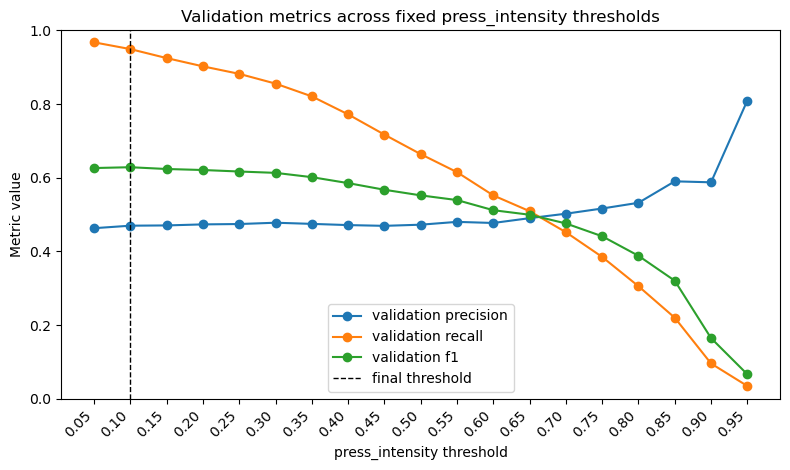

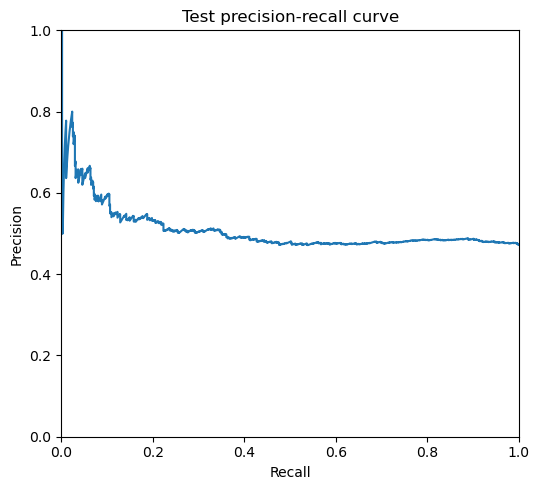

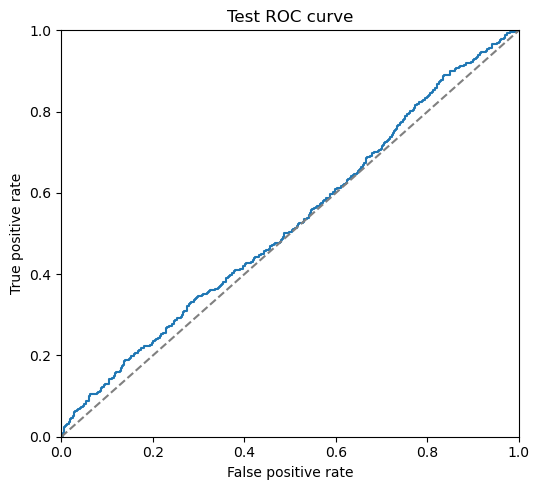

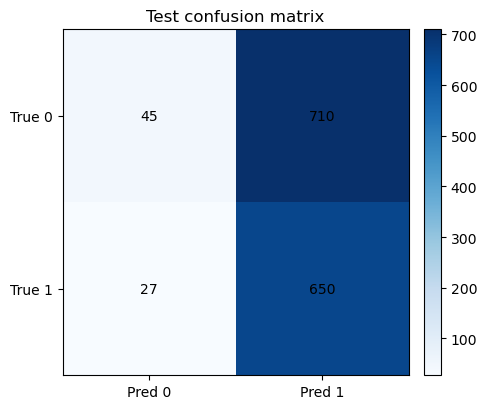

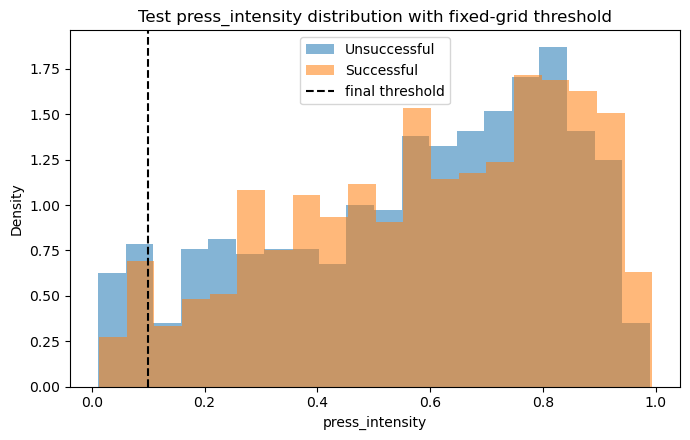

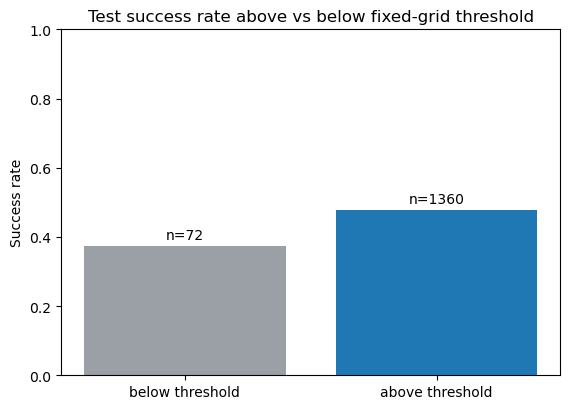

In [16]:
PLOT_THRESHOLD_CURVES_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_threshold_curves.png"
PLOT_PR_CURVE_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_pr_curve.png"
PLOT_ROC_CURVE_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_roc_curve.png"
PLOT_CONFUSION_MATRIX_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_test_confusion_matrix.png"
PLOT_TEST_DISTRIBUTION_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_test_distribution_threshold.png"
PLOT_ABOVE_BELOW_PATH = FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_success_above_below_threshold.png"

fig, ax = plt.subplots(figsize=(8, 4.8))
for metric in ["precision", "recall", "f1"]:
    ax.plot(validation_threshold_results["threshold"], validation_threshold_results[metric], marker="o", label=f"validation {metric}")
ax.axvline(final_threshold, color="black", linestyle="--", linewidth=1, label="final threshold")
ax.set_title("Validation metrics across fixed press_intensity thresholds")
ax.set_xlabel("press_intensity threshold")
ax.set_ylabel("Metric value")
ax.set_xticks(candidate_thresholds)
ax.set_xticklabels([f"{threshold:.2f}" for threshold in candidate_thresholds], rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_THRESHOLD_CURVES_PATH, dpi=220, bbox_inches="tight")
plt.show()

if test_df["press_success_any"].nunique() == 2:
    precision, recall, _ = precision_recall_curve(test_df["press_success_any"], test_df["press_intensity"])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(recall, precision)
    ax.set_title("Test precision-recall curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(PLOT_PR_CURVE_PATH, dpi=220, bbox_inches="tight")
    plt.show()

    fpr, tpr, _ = roc_curve(test_df["press_success_any"], test_df["press_intensity"])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--")
    ax.set_title("Test ROC curve")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    fig.savefig(PLOT_ROC_CURVE_PATH, dpi=220, bbox_inches="tight")
    plt.show()

cm = confusion_matrix(test_predictions["press_success_any"], test_predictions["press_success_pred"], labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["True 0", "True 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
ax.set_title("Test confusion matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(PLOT_CONFUSION_MATRIX_PATH, dpi=220, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for target, label in [(0, "Unsuccessful"), (1, "Successful")]:
    subset = test_predictions[test_predictions["press_success_any"].eq(target)]
    ax.hist(subset["press_intensity"], bins=20, alpha=0.55, label=label, density=True)
ax.axvline(final_threshold, color="black", linestyle="--", label="final threshold")
ax.set_title("Test press_intensity distribution with fixed-grid threshold")
ax.set_xlabel("press_intensity")
ax.set_ylabel("Density")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_TEST_DISTRIBUTION_PATH, dpi=220, bbox_inches="tight")
plt.show()

above_below = pd.DataFrame({
    "group": ["below threshold", "above threshold"],
    "success_rate": [test_threshold_metrics["success_rate_below_threshold"], test_threshold_metrics["success_rate_above_threshold"]],
    "n": [test_threshold_metrics["n_below_threshold"], test_threshold_metrics["n_above_threshold"]],
})
fig, ax = plt.subplots(figsize=(5.8, 4.2))
ax.bar(above_below["group"], above_below["success_rate"], color=["#9aa0a6", "#1f77b4"])
ax.set_ylim(0, 1)
ax.set_title("Test success rate above vs below fixed-grid threshold")
ax.set_ylabel("Success rate")
for idx, row in above_below.iterrows():
    label_height = row["success_rate"] + 0.02 if pd.notna(row["success_rate"]) else 0.02
    ax.text(idx, label_height, f"n={int(row['n'])}", ha="center")
fig.tight_layout()
fig.savefig(PLOT_ABOVE_BELOW_PATH, dpi=220, bbox_inches="tight")
plt.show()

In [17]:
if RUN_OPTIONAL_LOGISTIC_REGRESSION:
    logit = LogisticRegression(solver="lbfgs")
    logit.fit(train_df[["press_intensity"]], train_df["press_success_any"].astype(int))

    rows = []
    for split_name, split_df in [("train", train_df), ("validation", validation_df), ("test", test_df)]:
        probs = logit.predict_proba(split_df[["press_intensity"]])[:, 1]
        preds = (probs >= 0.5).astype(int)
        y_true = split_df["press_success_any"].astype(int).to_numpy()
        rows.append({
            "split": split_name,
            "accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
            "pr_auc": average_precision_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
        })

    logistic_results = pd.DataFrame(rows)
    logistic_results.to_csv(FIXED_THRESHOLD_OUTPUT_DIR / "fixed_press_intensity_logistic_regression_results.csv", index=False)
    display(logistic_results)
    print(f"Logistic coefficient: {float(logit.coef_[0][0]):.4f}; intercept: {float(logit.intercept_[0]):.4f}")

,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,train,0.551288,0.522656,0.333001,0.406811,0.562616,0.527130
1,validation,0.552754,0.518519,0.342159,0.412270,0.553533,0.533768
2,test,0.530028,0.504762,0.313146,0.386509,0.524200,0.509272


Logistic coefficient: 0.8153; intercept: -0.6317


## Thesis Interpretation Template

Use the final cell output below as the basis for the thesis text. The correct claim is that early research-based pressing intensity predicts pressing success. Do not claim that success is predicted before the press starts, because `press_intensity` is computed over the first second after press onset.

In [11]:
summary = (
    f"Using only research-paper press_intensity, the best fixed-grid validation threshold was {final_threshold:.2f}. "
    f"The fixed grid tested thresholds from {candidate_thresholds[0]:.2f} to {candidate_thresholds[-1]:.2f} "
    f"in steps of 0.05. On the untouched test set, presses above this threshold succeeded at "
    f"{test_threshold_metrics['success_rate_above_threshold']:.3f}, compared with "
    f"{test_threshold_metrics['success_rate_below_threshold']:.3f} below the threshold. "
    f"The threshold model achieved precision={test_threshold_metrics['precision']:.3f}, "
    f"recall={test_threshold_metrics['recall']:.3f}, F1={test_threshold_metrics['f1']:.3f}, "
    f"ROC-AUC={test_threshold_metrics['roc_auc']:.3f}, and PR-AUC={test_threshold_metrics['pr_auc']:.3f}."
)
print(summary)
print(f"Saved fixed-threshold outputs in: {FIXED_THRESHOLD_OUTPUT_DIR}")

Using only research-paper press_intensity, the best fixed-grid validation threshold was 0.05. The fixed grid tested thresholds from 0.05 to 0.95 in steps of 0.05. On the untouched test set, presses above this threshold succeeded at 0.473, compared with 0.333 below the threshold. The threshold model achieved precision=0.473, recall=0.986, F1=0.640, ROC-AUC=0.550, and PR-AUC=0.596.
Saved fixed-threshold outputs in: /Users/jonasaalbaekjensen/Desktop/MASTER_DS_SDU/Superliga_2024_2025_selected_TEST_DATA_3MATCHES/research_press_intensity_fixed_threshold_outputs


# 2. Methods and Materials

## 2.1 Overall Methodological Design

This thesis investigates whether the success of high pressing in professional football can be predicted from event and tracking data. The methodological design is built around one shared analytical pipeline that remains consistent across the project: match data are collected and synchronized, pressing episodes are detected from tracking data, tactical outcomes are labelled from event and possession data, features are extracted at episode level, and predictive models are evaluated using leakage-safe grouped validation. This shared framework provides the methodological foundation for all three approaches.

The three approaches should therefore not be understood as three completely separate studies. Rather, they represent iterative stages in the development of the same research pipeline. Approach 1 established the first working implementation of the pressing detector, labelling logic, and baseline feature space. Approach 2 refined the tactical scope by isolating settled high pressing and expanding the feature representation with causal temporal windows. Approach 3 introduced a more interpretable press-intensity threshold model to test whether a simple tactical rule could explain pressing success without relying on a broader black-box feature space. The shared components are described first, while the approach-specific differences are described afterwards.

## 2.2 Dataset and Data Sources

The empirical basis of the thesis is a full-season archive from the Danish Superliga 2024-2025 season. The raw archive contained 193 match folders with synchronized event and tracking feeds (`/Volumes/Lenovo_PS6/Superliga_2024_2025_ALL_SEASON/Matchfeeds`). Before any modelling was conducted, the match folders were audited for the files required by the pipeline: Second Spectrum tracking data, Second Spectrum metadata, Opta F24 event details, Opta F73 possession data, and SRML match-results data. This audit identified 192 tracking-ready matches. One match, 2024-10-06 SønderjyskE - FC Nordsjælland (2442608), was excluded because usable Second Spectrum tracking data were missing.

The exclusion was made solely because of data availability. No matches were removed based on tactical style, team identity, model performance, scoreline, or pressing outcome. The final sample therefore represents the complete set of matches from the available Superliga archive that could be processed consistently through the same tracking-event pipeline.

The data sources serve complementary purposes. Second Spectrum tracking data provide the high-frequency spatial positions of players and the ball. These data make it possible to identify pressure as movement in time and space. Opta F24 event data describe discrete on-ball actions, while Opta F73 possession data describe possession sequences and transitions. SRML match-results data provide match metadata such as teams, periods, lineups, and match identifiers. The combination of these feeds allows each detected pressing episode to be connected with the subsequent football outcome.

All data were transformed into a common internal representation before feature engineering. Tracking data were loaded through Kloppy where possible, while the Opta XML files were parsed separately. Opta minute and second values were converted into `gameClock` seconds within each period, and event coordinates were converted into metric pitch coordinates. Attack direction was inferred for each team and period so that spatial variables could be expressed relative to the opponent's goal. This standardization was necessary because pressing position must be interpreted tactically rather than as a raw coordinate value (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`).

## 2.3 Shared Pressing Episode Definition

The main unit of analysis is a pressing episode. A pressing episode is defined as a coherent defensive action in which one or more players actively move toward the ball carrier or ball zone in order to reduce the opponent's time, space, and passing options. This definition treats pressing as a collective tactical action rather than as a single defensive duel. It also separates pressing from passive compactness: a defender being close to the ball is not sufficient unless the movement and direction indicate active pressure.

Across the project, pressing was detected from tracking data using a multi-stage procedure. First, player-frame actions were identified by `detect_pressing_frames()` using movement speed, angle toward the ball, distance to the ball, closing speed, live-ball state, and ball height. Second, consecutive frame-level actions were grouped into player-level pressing runs using `group_pressing_runs()`. Third, overlapping or nearby same-team pressing runs were merged into episode-level observations using `cluster_runs_into_episodes()`. This structure was used because pressing normally unfolds over several frames and often involves multiple players coordinating pressure at the same time.

The detection parameters were refined through video validation. Detected situations were compared with clips of pressing actions, particularly high-pressure situations in the opponent's half. This process was used to tune the movement thresholds so that the detector captured active pressure and avoided classifying ordinary defensive positioning as pressing. The final press-detection parameters were validated by the Head of Data at SønderJyskE. This validation step is important because the tactical concept of pressing cannot be defined from tracking coordinates alone; it requires alignment between computational rules and football-domain interpretation (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_THESIS_KLOPPY_COLAB.ipynb`; definition folder used: `/Volumes/Lenovo_PS6/MASTER_SDU_2026/FIRST_PRESS_DEFINITION`).

## 2.4 Shared Success Labelling

The main supervised target is `press_success_any`, a binary label indicating whether a detected pressing episode led to a tactically successful outcome. The label was designed to connect spatial pressure with the practical objectives of high pressing. A press was not considered successful simply because it looked intense in the tracking data. It had to produce a favourable outcome for the pressing team.

The definition of success was informed by feedback from Odense Boldklub (OB). Under intense pressure, the desired outcomes were: winning the ball and creating a chance immediately after the regain, winning the ball and retaining possession, or forcing the opponent to play long, clear the ball, or send the ball out of play. These priorities were converted into event-based labelling rules. A pressing episode was labelled as successful if subsequent Opta event or possession data indicated a regain, sustained possession, chance creation, forced clearance, long-ball escape, or out-of-play outcome caused by the pressure. Episodes where the opponent retained controlled possession or progressed out of the pressured area were labelled unsuccessful.

The implementation links each detected pressing episode to later F73 possession information and F24 events. `label_pressing_episode_outcomes()` identifies relevant post-press events, and `add_press_success_targets()` combines them into `press_success_any`. A secondary value-oriented variable, `press_value_score`, was also produced in the broader pipeline, but the central modelling task in this thesis is the binary success classification. Verified Opta event mappings were used to keep these rules auditable, including event IDs such as `5 = out`, `6 = corner.awarded`, `12 = clearance`, and `50 = dispossessed` (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`).

## 2.5 Feature Engineering Strategy Across Approaches

Approaches 1 and 2 used the same general feature-engineering principle: predictor variables had to describe the tactical state of the press without including information from after the pressing outcome had occurred. This principle was essential for avoiding data leakage. Features were therefore computed from the tracking state at, immediately before, or immediately after press initiation, while success labels were computed separately from later event and possession outcomes. In practical terms, the features describe the conditions under which the press begins and develops; the labels describe what happened afterwards.

The common feature families in Approaches 1 and 2 included spatial pressure around the ball, team compactness, opponent shape, player-level distances, movement intensity, and pitch context. Examples include the distance from the ball to the nearest pressers, the number of defenders close to the ball, pressing-team surface area, stretch indices, ball location, closing speed, and pressing intensity. These features are grounded in the tactical assumption that successful high pressing depends on a combination of proximity to the ball, collective compactness, speed of pressure, spatial trapping, and the opponent's available escape routes.

Before modelling, the feature tables were cleaned to remove variables that could compromise evaluation validity. Label columns, identifiers, future or post-event variables, high-missingness columns, constant columns, and unstable artefacts were excluded from the model feature set. This produced model-ready feature views that could be evaluated consistently across grouped match-level splits (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`).

Although Approaches 1 and 2 shared these leakage-safe feature-engineering principles, they did not use identical final feature spaces. Approach 1 created the first broad spatial and physical feature set. Approach 2 retained the same validity logic but developed the final multi-feature settled high-press representation with richer tactical and temporal variables. Approach 3 used the same target-labelling logic, but its comparison model was intentionally based on a single feature design: research-derived press intensity. This separation is important because the approaches answer different methodological questions: whether pressing can be modelled from a broad baseline feature set, whether richer settled high-press context improves prediction, and whether intensity alone can explain pressing success.

## 2.6 Shared Model Training and Evaluation Strategy

The main predictive models were tree-based machine learning algorithms: Random Forest, XGBoost, and LightGBM. These models were selected because the data are tabular, non-linear, and interaction-heavy. Pressing success may depend on combinations of variables rather than isolated linear effects. For example, a short distance to the ball may only be valuable if the pressing team is compact, the opponent has limited passing lanes, and the ball is located near a trapping zone. Tree-based models can capture such threshold effects and interactions without requiring the same assumptions as linear models.

To avoid leakage between training and evaluation data, all splits were grouped by `match_name`. This means that episodes from the same match were not allowed to appear in both training and validation or test data. Grouped splitting is necessary because pressing episodes within a match are not independent: they share teams, tactical plans, score context, pitch conditions, and temporal continuity. Random row-level splitting would risk overestimating model performance.

Class balance was treated differently across the methodological development. In Approach 1, the broader pressing population and early target definitions made imbalance-aware modelling choices relevant, including balanced class weights and `scale_pos_weight` settings. In Approaches 2 and 3, the settled high-press filtering produced a substantially more balanced binary task, with successful and unsuccessful episodes appearing in roughly similar proportions. PR-AUC was therefore retained not because the final approaches had highly uneven class distributions, but because it is a useful ranking and retrieval metric for a noisy football outcome where analysts care about how well successful presses are prioritized among structurally similar unsuccessful ones. ROC-AUC, F1-score, precision, recall, confusion matrices, and Brier score were also used to describe ranking performance, threshold-dependent classification performance, and probabilistic calibration.

Model interpretation was performed using permutation importance and SHAP values. Permutation importance measures how much model performance decreases when a feature is disrupted, while SHAP values describe how individual features contribute to specific predictions. These methods allow the thesis to discuss not only whether pressing success is predictable, but also which tactical conditions appear to drive predicted success (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`).

## 2.7 Approach 1: First Working Pressing Pipeline

Approach 1 was the first complete implementation of the pressing-analysis pipeline. Its main purpose was to establish whether raw tracking and event data could be transformed into a usable supervised learning dataset. It therefore included the first working versions of the data-loading, tracking conversion, pressing detection, episode grouping, outcome labelling, and baseline feature-extraction steps (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_THESIS_KLOPPY_COLAB.ipynb`; definition folder used: `/Volumes/Lenovo_PS6/MASTER_SDU_2026/FIRST_PRESS_DEFINITION`).

Because this was the first approach, it did not differ from an earlier established pipeline. Instead, it created the methodological baseline. The focus was on defining pressure from first principles using tracking-derived movement and spatial criteria. The feature space emphasized direct spatial and physical descriptions of pressing: nearest-presser distances, number of pressers within fixed radii, pressing-team surface area, pressing stretch index, opponent team shape, ball speed, nearest presser speed, sprinting pressers, average pressing-team speed, closing speed, and a probabilistic pressing-intensity score.

Approach 1 was also the stage where imbalance-aware modelling choices were most relevant. The notebook used or proposed settings such as `class_weight="balanced"` for Logistic Regression, Random Forest, and LightGBM, and `scale_pos_weight` for XGBoost. These settings should be interpreted as part of the first broad modelling setup, where the aim was to make the baseline robust to uneven target distributions. This imbalance framing should not be transferred uncritically to the later settled high-press approaches, where the target distribution became substantially more balanced.

The central contribution of Approach 1 was feasibility. It showed that the project could move from raw match feeds to episode-level observations with meaningful labels. However, it also exposed a limitation. The detected pressing population could contain several tactically different situations, including transitional counterpresses and more organized high presses. These situations may share movement features but differ in tactical meaning. This motivated a second approach where the target population was defined more narrowly.

## 2.8 Approach 2: Settled High Press and Advanced Temporal Features

Approach 2 differed from Approach 1 by refining the tactical scope and expanding the feature representation. Instead of modelling all detected pressing actions together, the analysis was restricted to settled high pressing. This was done to focus on the specific tactical phenomenon most relevant to the thesis: organized pressure high up the pitch after the opponent has possession. Counterpress candidates were excluded, recent restart situations were removed where relevant, and the final high-press scope used field-position logic such as `pressing_progress_to_opponent_goal >= 0.60` (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`; definition folder used: `SECOND_PRESS_DEFINITION_SETTLED_HIGH_PRESS_NEW_PRESS_FEAT`).

This change was necessary because Approach 1 was too broad for the final research question. A counterpress after losing the ball and a settled high press against an opponent build-up may both involve pressure, but they arise from different tactical states. Counterpressing is often chaotic, immediate, and transition-based. Settled high pressing is more structured and depends more on collective positioning, pitch control, and coordinated restrictions of passing options. By isolating settled high pressing, Approach 2 made the modelling population more coherent.

Approach 2 also introduced causal temporal windows. Instead of representing a press only through a single snapshot, features were computed across `pre_2s`, `pre_1s`, `start`, and `early_1s` windows. Frame-level features were summarized using statistics such as mean, maximum, and standard deviation. This allowed the model to compare the information available at press start with the information contained in the first second of pressure. The resulting `start_only` and `early_1s` feature views made it possible to test whether early pressing dynamics improve prediction beyond static press-start structure.

The advanced feature set included tactical concepts such as local overload, passing-lane occlusion, trap intensity, escape difficulty, compact pressure, opponent shape, ball location, pressing intensity, and temporal deltas between pre-press and early-press windows. This represented a methodological shift from simple spatial proximity to richer tactical context. Approach 2 therefore differed from Approach 1 in both population definition and feature design: it narrowed the sample to settled high pressing and described each press with more temporally informed, causally valid predictors.

After the settled high-press filtering, the modelling target was approximately balanced rather than highly uneven. The local model-ready manifest recorded 626 settled high-press rows, with 315 clean start-time features and 430 clean early-press features, while the final full-season modelling workflow used the same settled high-press logic at larger scale. This balance matters methodologically because the final multi-feature model should be discussed as a difficult, noisy football classification task, not primarily as an imbalance-correction exercise (notebook and manifest used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_TEST_NEW_FEATURES.ipynb`; `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/press_model_feature_manifest.json`).

## 2.9 Approach 3: Press-Intensity Threshold Benchmark

Approach 3 used the same pressing-episode definition and target-labelling logic as the previous approaches, but it changed the feature engineering for the comparison model. Instead of using the broader spatial, contextual, and temporal feature sets from Approaches 1 and 2, Approach 3 represented pressure through one research-derived feature design: press intensity. This feature is based on player movement toward the ball and estimated time-to-intercept, following the logic of the research-paper concept "Pressing Intensity: An Intuitive Measure for Pressing in Soccer" (source to be inserted in the final reference list).

The first step in Approach 3 was to compute research-oriented press-intensity variables for each episode. Active pressers were evaluated using estimated velocity, time to intercept, and individual pressure probability. These individual probabilities were aggregated into episode-level measures such as `press_intensity`, `press_intensity_peak`, `press_intensity_std`, `max_individual_pressure_mean`, `n_active_pressers_mean`, and `n_pressers_evaluated_mean`. This produced a compact representation of pressure intensity while retaining the original episode identifiers, match names, team information, split assignment, and success labels (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/MASTER_PRESS_INTENSITY_MODEL.ipynb`).

Approach 3 should therefore be interpreted as a reduced-feature benchmark rather than as the same type of feature engineering used in Approach 2. It tests whether intensity alone can measure or approximate successful pressing, while the multi-feature model tests whether additional information about spatial structure, opponent shape, trapping geometry, passing options, and early temporal dynamics improves prediction. This comparison is useful because press intensity is easier to communicate tactically, but it may be too narrow to capture all the conditions that determine whether a high press succeeds.

The second step tested threshold rules. Candidate thresholds were evaluated across a fixed grid, and model performance was assessed on an untouched test set. The threshold model predicted a press as more likely to succeed when its intensity exceeded the selected threshold. Evaluation included the success rate above and below the threshold, as well as precision, recall, F1-score, ROC-AUC, and PR-AUC (notebook used: `Superliga_2024_2025_selected_TEST_DATA_3MATCHES/Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb`).

The class-balance interpretation for Approach 3 follows the settled high-press population rather than the broader Approach 1 setting. The full-season intensity notebook loaded 6,851 settled high-press episodes, split into 4,348 training episodes, 1,071 validation episodes, and 1,432 test episodes. The local threshold test set used in the current Results chapter had a base success rate of approximately 0.471. These values indicate an approximately balanced binary comparison, so the press-intensity benchmark should be framed as a reduced-feature interpretability test rather than as a response to a highly uneven class distribution.

This approach differs most clearly from Approach 2 in interpretability. Approach 2 asks whether a rich collection of spatial, contextual, and temporal features can predict pressing success. Approach 3 asks whether one central tactical quantity, pressure intensity, is sufficient to create a useful rule. If the full machine learning models outperform the threshold benchmark, this supports the argument that pressing success depends on more than intensity alone. It would suggest that geometry, opponent structure, field position, escape options, and timing all contribute to whether a high press succeeds.

## 2.10 Summary of the Final Methodological Flow

The final thesis methodology is therefore organized around a shared pipeline with three methodological iterations. The shared pipeline defines the data sources, synchronizes event and tracking feeds, detects pressing episodes, labels success outcomes, extracts leakage-safe features, trains models using grouped match-level validation, and interprets results using model-interpretability tools. This avoids repeating identical material inside each approach section.

The approach sections then explain only what changed. Approach 1 establishes the first working pipeline and baseline spatial-physical feature set. Approach 2 changes the tactical scope to settled high pressing and introduces advanced temporal feature windows. Approach 3 changes the modelling philosophy by testing an interpretable press-intensity threshold benchmark. Written this way, the chapter separates what is common across the thesis from what is specific to each methodological iteration.

# 3. Results

This chapter presents the empirical findings from the full-season modelling pipeline for predicting successful settled high pressing in the Danish Superliga 2024-2025 season. The purpose of the chapter is threefold: first, to compare the candidate machine learning models; second, to report the predictive performance of the selected final model; and third, to translate the model outputs into football-relevant interpretations of successful high pressing. Only full-season results are reported in this chapter. Smaller development runs and implementation tests are treated as code-development steps and are not included as formal empirical results.

The final model selected for thesis reporting is the XGBoost classifier trained on the reduced `moderate_0_90` feature set consisting of 180 active features. This model was selected by the researcher as the final/best model and is therefore treated as the central result model in the sections below. The reporting emphasizes Precision-Recall AUC (PR-AUC) as a primary ranking metric because the central question is not only whether the model separates classes overall, but whether it can prioritize successful pressing episodes with useful precision and recall in a noisy football setting where successful and unsuccessful high presses may be structurally similar (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

## 3.1 Model Selection and Predictive Performance

### 3.1.1 Model Comparison

Three tree-based classifiers were compared as candidate models: Random Forest, XGBoost, and LightGBM. Each model was evaluated using the same reduced feature set and the same train, validation, and test structure. The validation phase was used to select classification thresholds through F1-based threshold tuning, while the held-out test set was used for final performance comparison. The validation set contained 1,071 pressing episodes, of which 491 were successful and 580 were unsuccessful. The training set contained 4,348 pressing episodes (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

On the validation set, the three models performed similarly but not identically. Random Forest achieved a validation PR-AUC of 0.5770, ROC-AUC of 0.6161, F1-score of 0.6411, precision of 0.4918, recall of 0.9206, and Brier score of 0.2374. XGBoost achieved a validation PR-AUC of 0.5789, ROC-AUC of 0.6205, F1-score of 0.6379, precision of 0.5072, recall of 0.8595, and Brier score of 0.2450. LightGBM achieved a validation PR-AUC of 0.5633, ROC-AUC of 0.6044, F1-score of 0.6410, precision of 0.4977, recall of 0.9002, and Brier score of 0.2513. These results indicate that XGBoost had the strongest validation PR-AUC and ROC-AUC, while Random Forest produced the lowest validation Brier score. The difference between Random Forest and XGBoost was therefore not one of complete dominance; rather, XGBoost offered the strongest ranking performance, whereas Random Forest showed slightly better validation calibration according to the Brier score (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; output file used: `full_season_press_model_validation_thresholds.json`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

The held-out test set provided clearer separation between the models. XGBoost achieved the highest test PR-AUC (0.6448), highest test ROC-AUC (0.6503), and highest test F1-score (0.6538). Random Forest achieved a test PR-AUC of 0.6207, ROC-AUC of 0.6321, and F1-score of 0.6490. LightGBM achieved a test PR-AUC of 0.6311, ROC-AUC of 0.6377, and F1-score of 0.6512. The test results therefore support using XGBoost as the final model because it produced the strongest ranking and threshold-based classification performance on the untouched test set (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

PR-AUC is especially relevant in this setting because high pressing success is not only an accuracy-driven task. A useful model must retrieve successful pressing episodes among many structurally similar unsuccessful ones. ROC-AUC describes the model's overall ranking ability across both classes, but PR-AUC is more sensitive to the model's ability to retrieve successful episodes without overwhelming the analyst with false positives. For this reason, the test PR-AUC of 0.6448 is treated as the primary performance result for the selected XGBoost model.

### 3.1.2 Final Selected Model

The final selected model is the XGBoost classifier trained on the 180-feature reduced numerical feature set. The selected validation threshold for XGBoost was 0.2799, obtained through validation-set F1 threshold analysis. At this threshold, XGBoost achieved a validation F1-score of 0.6379, precision of 0.5072, and recall of 0.8595. This threshold was then carried into test-set evaluation, where the final model achieved a test PR-AUC of 0.6448 and test ROC-AUC of 0.6503 (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; output file used: `full_season_press_model_validation_thresholds.json`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

The choice of XGBoost is defensible for several reasons. First, it produced the strongest test PR-AUC among the three candidate models, which is the most important metric for assessing ranking and retrieval quality in the final settled high-press task. Second, it also produced the strongest test ROC-AUC and F1-score, suggesting that its advantage was not limited to one metric. Third, XGBoost supports SHAP-based interpretation, which is valuable because this thesis aims not only to classify pressing episodes but also to interpret which tactical conditions are associated with success. Finally, the model's feature-importance and SHAP outputs provide a route from predictive performance to football interpretation, allowing the results to be discussed in terms of pressing intensity, spatial control, trap dynamics, and opponent escape difficulty.

The model should not be interpreted as universally superior in all possible settings. The validation results show that Random Forest had a lower Brier score than XGBoost, indicating somewhat better validation calibration in that comparison. However, the final reporting prioritizes XGBoost because the user-selected final model also performed best on the held-out test set for PR-AUC, ROC-AUC, and F1-score. The model selection is therefore based on a combination of predictive performance, test-set ranking strength, and interpretability rather than on a single isolated metric.

### 3.1.3 Classification Performance and Error Profile

On the held-out test set of 1,432 pressing episodes, the selected XGBoost model achieved a PR-AUC of 0.6448, ROC-AUC of 0.6503, F1-score of 0.6538, precision of 0.5121, and recall of 0.9040. The confusion matrix contained 612 true positives, 583 false positives, 172 true negatives, and 65 false negatives. In practical terms, this means that the model captured most successful pressing episodes, but it also classified many unsuccessful episodes as successful (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

The high recall of 0.9040 indicates that the model was sensitive to successful pressing situations: only 65 successful pressing episodes were missed on the test set. This is useful if the model is intended to identify a broad set of potentially successful high-pressing situations for tactical review. However, the precision of 0.5121 shows that the model's positive predictions were not always correct. Of all episodes predicted as successful, just over half were actually successful. This reflects the difficulty of the task: football outcomes are noisy, and a pressing situation that has many favourable structural characteristics may still fail because of technical execution, opponent skill, ball bounce, referee decisions, or context not fully captured by the features.

The false positives and false negatives have different football meanings. A false positive represents an episode where the model predicted pressing success, but the opponent escaped, retained control, or avoided the target outcome. These cases may correspond to situations that looked structurally favourable for the pressing team but were resolved effectively by the team in possession. A false negative represents an episode where the model predicted failure, but the press succeeded. These may include episodes where success came from an individual action, opponent mistake, or contextual factor not strongly represented in the model. The error profile therefore suggests that the model is better suited as an analytical screening tool than as a deterministic rule for predicting single pressing outcomes.

## 3.2 Overview of Results

The overall results indicate that successful settled high pressing contains a measurable signal in the tracking-derived feature space. The selected XGBoost model performed above a naive or purely random expectation, with test PR-AUC of 0.6448 and ROC-AUC of 0.6503. These values do not imply perfect prediction, but they do show that pressing success is not random with respect to the engineered tactical features. The model was able to use spatial, temporal, and intensity-based information to rank successful pressing episodes above unsuccessful ones with meaningful, though imperfect, discrimination.

The comparison across candidate models suggests that the predictive task is learnable but challenging. All three tree-based models produced broadly similar F1-scores on the test set, ranging from 0.6490 to 0.6538. This narrow range indicates that the result is not simply a quirk of one algorithm. At the same time, XGBoost's stronger PR-AUC and ROC-AUC suggest that its probability ranking was more informative than the alternatives in the final test evaluation. The similarity between the models also implies that the feature set itself carries the main tactical information, while algorithm choice provides incremental performance differences.

The classification threshold chosen for XGBoost favoured recall over precision. This is visible in the test confusion matrix: the model correctly identified 612 successful presses but also produced 583 false positives. In football-analysis terms, this behaviour may be acceptable if the goal is to retrieve many potentially successful pressing situations for review. If the goal were instead to create a highly selective alert system, a different threshold with higher precision and lower recall might be more appropriate. The current threshold therefore reflects a modelling choice aligned with the validation F1 objective rather than a universal tactical decision threshold.

The results also show that the model benefits from a broad contextual feature space. The most important XGBoost features were not limited to one type of variable. They included pressure intensity, passing-lane occlusion, area ratio, trap intensity, pressing stretch, number of pressers, escape difficulty, opponent width, and nearest-presser distance. This pattern suggests that high-pressing success is associated with the interaction of intensity and spatial context rather than with a single isolated feature family (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

## 3.3 Football Contextual Findings

The football interpretation of the results is that successful high pressing appears to depend on both the amount of pressure applied and the structure around that pressure. The selected XGBoost model assigned high importance to pressing intensity before and during the first second of the press, but it also relied on variables describing passing-lane occlusion, trap intensity, area ratios, pressing-team stretch, opponent width, escape difficulty, and nearest-presser distance. In tactical terms, this suggests that pressure is most meaningful when it is embedded in a structure that limits the opponent's next action.

The feature-importance results point toward a model that values early pressing dynamics. Several of the most important variables are measured in the `early_1s` window, including `early_1s_passing_lane_occlusion_max`, `early_1s_pressing_intensity_mean`, `early_1s_area_ratio_mean`, `early_1s_trap_intensity_max`, `early_1s_press_stretch_index_max`, `early_1s_passing_lane_occlusion_mean`, `early_1s_n_pressers_5m_mean`, and `early_1s_escape_difficulty_mean`. This supports the idea that the first second after pressure begins contains important information about whether the press is likely to succeed. The model does not rely only on the initial snapshot; it also responds to how the pressing situation develops immediately after initiation.

At the same time, pre-press context also matters. `pre_1s_pressing_intensity_mean`, `pre_1s_trap_intensity_std`, `pre_2s_n_pressers_10m_mean`, `pre_1s_passing_lane_occlusion_mean`, and `pre_2s_escape_difficulty_mean` appeared among the important XGBoost features. This indicates that successful pressing may be partly prepared before the formal start of the detected episode. The model appears to value whether the pressing team was already close, compact, and positioned to limit options before pressure fully materialized.

## 3.3.1 Features Associated With Successful Pressing

The XGBoost built-in feature-importance plot identified `pre_1s_pressing_intensity_mean` as the strongest individual feature. Other highly ranked features included `early_1s_passing_lane_occlusion_max`, `early_1s_pressing_intensity_mean`, `early_1s_area_ratio_mean`, `pre_1s_trap_intensity_std`, `early_1s_trap_intensity_max`, `early_1s_press_stretch_index_max`, `early_1s_passing_lane_occlusion_mean`, `pre_2s_n_pressers_10m_mean`, `pre_1s_passing_lane_occlusion_mean`, `early_1s_opp_team_width_mean`, `early_1s_n_pressers_5m_mean`, `early_1s_escape_difficulty_mean`, `pre_2s_escape_difficulty_mean`, and `start_dist_nearest_1_max` (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

These features can be grouped into several football concepts. The first is pressure intensity, represented by pre-press and early-press intensity variables. The second is access to the opponent, represented by nearest-presser distance and number of pressers within five or ten meters. The third is spatial restriction, represented by passing-lane occlusion, trap intensity, and escape difficulty. The fourth is collective structure, represented by area ratio, pressing stretch index, and opponent team width. This grouping is more meaningful than listing column names alone because it shows that the model is not merely learning one proxy for pressure. Instead, it combines pressure, access, compactness, and opponent constraint.

The SHAP summary plot reinforces this interpretation. The highest-ranked SHAP features included `early_1s_area_ratio_mean`, `early_1s_press_stretch_index_max`, `early_1s_pressing_intensity_mean`, `pre_1s_pressing_intensity_mean`, `early_1s_trap_intensity_max`, `early_1s_mean_time_to_intercept_std`, `pre_2s_escape_difficulty_mean`, `pre_2s_ball_dist_to_sideline_max`, `early_1s_team_length_mean`, `early_1s_avg_pressing_team_speed_max`, `pre_2s_dist_to_goal_line_mean`, `early_1s_centroid_dist_to_sideline_std`, `pre_1s_trap_intensity_std`, `early_1s_ball_y_std`, `early_1s_dist_to_central_axis_max`, `delta_team_length_early_vs_pre1`, `early_1s_pressing_intensity_std`, `pre_2s_ball_x_mean`, `early_1s_nearest_presser_speed_std`, and `previous_event_seconds_before_press`. These SHAP results indicate that the model's predictions were influenced by multiple tactical dimensions rather than a single dominant variable (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

It is important to distinguish the two interpretation methods. Built-in feature importance indicates which variables the model used strongly in its tree structure. SHAP values describe how feature values contributed to individual predictions and show whether high or low values tended to push predictions toward success or failure. Neither method proves causality. Instead, together they indicate which tactical conditions were most associated with the model's successful-press predictions.

## 3.3.2 Derived Pressing Triggers

The model-derived findings suggest several pressing triggers that are associated with successful high pressing. The first trigger is early pressure intensity. Both `pre_1s_pressing_intensity_mean` and `early_1s_pressing_intensity_mean` were highly ranked, indicating that successful presses are associated with strong pressure before and immediately after the press begins. This does not mean that intensity alone guarantees success, but it suggests that the speed and immediacy of the pressure are central parts of the successful-press profile.

The second trigger is restriction of the opponent's passing options. Passing-lane occlusion and escape-difficulty variables appeared repeatedly among important features. This indicates that the model associated successful pressing with situations where the opponent had fewer clean routes away from pressure. In football terms, the press is more likely to succeed when the first defender's pressure is supported by surrounding players who block or discourage the next pass.

The third trigger is spatial trapping. Trap-intensity variables and sideline-related SHAP features suggest that location and geometry matter. Pressing near constrained areas, particularly where the ball is closer to the sideline or where the opponent's available space is reduced, appears to be associated with successful outcomes. This aligns with the tactical principle that the sideline can function as an extra defender by reducing the number of available escape directions.

The fourth trigger is collective compactness and shape. Features such as area ratio, pressing stretch index, team length, and opponent width indicate that the model used information about team structure, not only individual actions. Successful pressing appears more likely when the pressing team can combine pressure on the ball with a compact supporting shape and when the opponent's structure is vulnerable to being constrained. The model-derived triggers therefore suggest that successful high pressing is not only a matter of individual pressure, but also of whether the surrounding spatial context limits the opponent's next action.

## 3.3.3 Multi-Feature Model vs. Press-Intensity Model

The selected multi-feature XGBoost model can be compared with two one-feature press-intensity benchmarks from the intensity notebook: the deterministic fixed-threshold rule and the optional one-feature logistic regression. This distinction is important because the fixed-threshold rule and logistic regression are related but not identical evaluations. The fixed-threshold rule uses the direct decision rule `press_success_pred = 1 if press_intensity >= threshold else 0`, whereas the logistic regression fits a one-feature probabilistic model using only `press_intensity` (notebook used: `Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb`).

For the deterministic fixed-threshold rule, the selected fixed-grid validation threshold was 0.05. On its untouched test set of 153 episodes, this rule achieved precision of 0.473, recall of 0.986, F1-score of 0.640, ROC-AUC of 0.550, and PR-AUC of 0.596. Presses above the threshold succeeded at a rate of 0.473, compared with 0.333 below the threshold. The base test success rate was 0.471, and the threshold classified 150 of 153 episodes as above threshold. The optional one-feature logistic regression output, however, reported a lower test F1-score of 0.5745. The Results section therefore treats 0.640 as the fixed-threshold rule's F1-score and 0.5745 as the logistic-regression intensity-only test F1-score, rather than mixing the two benchmark definitions (notebook used: `Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb`; output folder used: `research_press_intensity_fixed_threshold_outputs`).

This comparison suggests that press intensity alone contains some useful signal, but it is not sufficient to match the broader multi-feature model. The intensity-only fixed-threshold rule achieved a PR-AUC of 0.596, while the selected XGBoost model achieved a test PR-AUC of 0.6448 on the final multi-feature evaluation. The threshold model also had extremely high recall but very low specificity, with only 2 true negatives and 79 false positives in its test confusion matrix. This indicates that the low threshold captured nearly all successful presses but did little to separate successful and unsuccessful episodes.

The practical interpretation is that intensity is useful but incomplete. A simple threshold on pressure intensity is easy to communicate and may serve as a transparent tactical baseline. However, the multi-feature model adds information about passing-lane occlusion, escape difficulty, trap intensity, compactness, opponent width, nearest-presser distance, and early spatial dynamics. The stronger performance of the multi-feature model therefore supports the argument that successful high pressing depends on more than applying pressure. It also depends on the geometry of the press, the opponent's available options, the location of the ball, and the timing of collective movement.

## 3.4 Robustness and Generalization

The available final-result artifacts provide several forms of evidence relevant to generalization, but they do not contain a complete separate team-holdout or temporal-split robustness report in the extracted final folder. The strongest available generalization evidence is therefore the held-out test-set evaluation and the grouped train-validation-test design. Because the modelling split is organized by match rather than by random episode rows, the reported test performance is less vulnerable to leakage from repeated episodes within the same match (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

A second robustness-related check concerns feature redundancy. The reduced feature set contained 180 active features. A correlation analysis found 24 feature pairs with correlation greater than 0.85. By filtering one feature from each highly correlated pair, 23 features were removed, leaving a strictly independent feature list of 157 features. The highest correlations involved related temporal-window versions of similar tactical variables, such as area ratio, opponent stretch index, opponent shape aspect ratio, opponent team width, pressing stretch index, number of pressers within ten meters, passing-lane occlusion, and escape difficulty. This indicates that the feature space contained expected tactical redundancy across adjacent time windows, but that the modelling workflow explicitly identified and documented this redundancy (notebook used: `LESS_FEATURES_NEW_HYPER.ipynb`; source folder used: `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS`).

The final model should therefore be interpreted as showing meaningful generalization to the held-out test set rather than as a definitive proof of universal generalization across teams, seasons, or tactical systems. Additional robustness tests, particularly team holdout and chronological split validation, would strengthen the claim further if included in future reporting. Based on the extracted final evidence, the safest conclusion is that XGBoost generalized best among the evaluated candidate models on the available full-season held-out test split.

## 3.5 Summary of Results

The results show that successful settled high pressing in the Danish Superliga 2024-2025 season can be predicted with meaningful, though imperfect, accuracy from tracking-derived tactical features. The user-selected final model, XGBoost, achieved the strongest held-out test performance among the evaluated tree-based models, with PR-AUC of 0.6448, ROC-AUC of 0.6503, and F1-score of 0.6538. Its high recall indicates that it captured most successful pressing episodes, while its moderate precision shows that football-specific uncertainty and contextual complexity remain substantial.

The football interpretation is that successful pressing is associated with a combination of early intensity and spatial restriction. Important features included pressing intensity before and during the first second of pressure, passing-lane occlusion, trap intensity, escape difficulty, compactness-related area ratios, pressing stretch, opponent width, and nearest-presser distance. The press-intensity benchmark showed that intensity alone contains signal, but the stronger multi-feature XGBoost performance suggests that high pressing success depends on broader tactical context. Overall, the results support the thesis argument that tracking and event data can be used not only to detect pressing episodes, but also to identify the spatial and dynamic conditions under which high pressing is more likely to succeed.

# 4. Discussion

This chapter interprets the empirical findings presented in the Results chapter and discusses their implications for football analytics, high-pressing theory, applied performance analysis, and future research. The central result is that successful settled high pressing in the Danish Superliga can be predicted with meaningful, although imperfect, accuracy from tracking-derived tactical features. The selected XGBoost model outperformed the simpler press-intensity benchmarks, suggesting that pressing success is not explained by physical pressure alone. Instead, the results indicate that intensity becomes most valuable when combined with spatial restriction, timing, compact support, and opponent constraint.

## 4.1 Interpretation of the Main Predictive Result

The final XGBoost model achieved the strongest overall performance among the evaluated tree-based models, with a test PR-AUC of 0.6448, ROC-AUC of 0.6503, and F1-score of 0.6538. These values indicate that the engineered feature space contains meaningful information about whether a settled high press will succeed. The result is important because it suggests that successful pressing is not random with respect to tracking-derived spatial and dynamic conditions. Instead, the model was able to learn patterns that distinguish successful pressing episodes from unsuccessful ones better than a simple baseline or single-variable intensity rule.

At the same time, the model performance should be interpreted as meaningful rather than definitive. Football is a highly dynamic and adversarial environment, and pressing success depends not only on the pressing team's structure but also on the opponent's technical quality, decision-making, body orientation, passing options, match context, and individual execution. The XGBoost model captures many features related to space and movement, but it cannot fully observe every relevant tactical or technical detail. Therefore, the model's imperfect performance is not simply a weakness of the algorithm; it reflects the complexity of the phenomenon being modelled.

The classification profile provides further insight. The model's recall of 0.9040 shows that it identified most successful pressing episodes in the test set. In practical terms, this means that the model is sensitive to the conditions under which successful high pressing tends to occur. However, the precision of 0.5121 shows that many episodes predicted as successful were not successful according to the outcome label. This trade-off suggests that the model is well suited as a screening or analysis-support tool, but not as an automatic tactical judgement system. It can help identify promising pressing situations for review, while still requiring human interpretation to understand why some apparently favourable situations do not result in success.

## 4.2 Why Pressing Success Is Predictable but Imperfect

The results show that pressing success is predictable to a meaningful degree because pressing is partly structured. Teams do not press randomly. Successful high pressing often involves coordinated pressure on the ball, compact support behind the first presser, restricted passing lanes, and positioning that reduces the opponent's options. These aspects are visible in tracking data and can therefore be represented through engineered features such as pressing intensity, passing-lane occlusion, escape difficulty, trap intensity, compactness, and nearest-presser distance.

However, pressing success remains imperfectly predictable because the outcome of a press depends on more than the spatial structure at the moment of pressure. A well-organized press can fail if the opponent executes a technically difficult pass, uses a press-resistant player, wins a duel, or benefits from a small timing advantage. Similarly, a less structurally optimal press can succeed if the opponent miscontrols the ball, selects a poor pass, or is forced into an error by an individual defensive action. These micro-level events are only partly captured by event and tracking data.

This explains why the model produced both false positives and false negatives. False positives may represent situations where the tactical structure looked favourable for the pressing team, but the opponent solved the pressure. False negatives may represent situations where the model did not recognize the press as structurally favourable, but the press succeeded due to execution, opponent error, or a contextual factor not fully represented by the feature set. In this sense, the errors are not only statistical failures; they are analytically interesting cases that can reveal the difference between structural potential and actual football execution.

The imperfection of the model is therefore consistent with the nature of the research question. The thesis does not claim that pressing success can be determined mechanically from tracking data. Rather, it shows that tracking and event data contain a measurable tactical signal that can support the analysis of high pressing. The model should be understood as a probabilistic description of pressing conditions, not as a deterministic explanation of every individual outcome.

## 4.3 Intensity Alone Is Not Enough

The comparison with the press-intensity benchmark clarifies the role of intensity in pressing success. The fixed-grid threshold model showed that research-based `press_intensity` contains predictive signal. However, the selected fixed threshold was very low at 0.05, which caused the model to classify nearly all test episodes as successful. This produced a high recall of 0.986 and an F1-score of 0.640, but the specificity was only 0.025. In other words, the threshold rule captured almost all successful presses, but it failed to identify most unsuccessful ones.

This explains why the fixed-threshold F1-score appears close to the XGBoost F1-score. F1-score combines precision and recall but does not reward true negatives directly. Because the fixed-threshold model predicted almost every episode as successful, it achieved high recall, which raised the F1-score despite weak separation between successful and unsuccessful episodes. The ROC-AUC of 0.550 and PR-AUC of 0.596 provide a more cautious interpretation: intensity alone ranks episodes better than chance, but not as well as the multi-feature model.

The optional one-feature logistic regression using only `press_intensity` further supports this interpretation, with a lower test F1-score of 0.5745. Taken together, the intensity-only benchmarks suggest that intensity is relevant, but incomplete. Intensity appears to be a necessary part of the pressing-success profile, but not a sufficient explanation on its own. A press can be intense without being well structured, and a high-pressure action may fail if the opponent still has available passing lanes or if the pressing team lacks compact support around the ball.

The stronger performance of XGBoost indicates that additional contextual features add value. Passing-lane occlusion, trap intensity, escape difficulty, area ratio, opponent width, nearest-presser distance, and early-window dynamics all contribute to a richer description of the pressing situation. The central tactical interpretation is therefore that successful high pressing is not simply a matter of applying pressure. It is a matter of applying pressure in a spatial and temporal context that restricts the opponent's next action.

## 4.4 Football-Theoretical Interpretation

The findings align with the football-theoretical view of pressing as a collective action rather than an isolated physical effort. In coaching language, pressing is often described as a coordinated attempt to reduce the opponent's time and space, force play toward predictable zones, and create conditions for a regain or low-control opponent action [citation needed]. The model's important features support this interpretation because they include both pressure on the ball and contextual variables describing the surrounding structure.

Passing-lane occlusion and escape difficulty are especially relevant. These features reflect whether the opponent has clean routes out of pressure. Their importance suggests that successful pressing is associated with situations where the pressing team not only approaches the ball but also reduces the opponent's available choices. This is consistent with the tactical idea that pressure becomes more effective when it is supported by cover shadows, compact distances, and coordinated positioning behind the first presser [citation needed].

Trap intensity and sideline-related variables also have a clear football interpretation. Pressing near constrained areas can reduce the opponent's field of action, particularly when the sideline limits one direction of escape. In this sense, the sideline can function as an additional spatial constraint. The model's use of trap-related and location-related features suggests that where pressure occurs matters, not only how much pressure is applied.

The importance of early-window dynamics is also tactically meaningful. Several influential features were measured in the first second after pressure began. This suggests that the immediate development of the press carries important information about its likely outcome. A press may begin with similar initial distances, but the first second can reveal whether the pressing team closes space collectively, blocks passing options, and forces the opponent toward a constrained decision. This supports the view that pressing is a temporal process rather than a static event.

## 4.5 Practical Implications for Analysts and Coaches

The model has practical value as a decision-support tool for performance analysts and coaches. Because the XGBoost model achieved high recall, it can be useful for retrieving a broad set of potentially successful high-pressing situations for video review. This is valuable in applied analysis, where the goal is often not to replace human judgement but to reduce the search space and direct attention toward relevant clips.

The moderate precision means that model predictions should not be treated as automatic tactical truth. Many predicted successes were not successful according to the label. However, these false positives can still be useful. They may represent situations where the pressing structure looked favourable but the execution failed, or where the opponent solved the pressure effectively. Such cases can be particularly informative for coaching because they separate the quality of the pressing structure from the final outcome.

The derived feature patterns can also support a more structured vocabulary for coaching discussions. Instead of describing a press only as intense or passive, analysts can evaluate whether the press included early pressure intensity, multiple pressers near the ball, compact support, blocked passing lanes, high escape difficulty, and favourable trap location. This makes the model useful not only as a predictor but also as a framework for describing why a press was likely or unlikely to succeed.

For coaches, the findings suggest that training high pressing should not focus only on running intensity. Intensity is important, but the model indicates that pressure becomes more valuable when combined with spatial control. Training tasks that emphasize coordinated cover shadows, compact distances, sideline traps, and immediate collective reactions after the press begins may therefore be more aligned with the patterns associated with successful pressing. These implications should be treated as analytical suggestions rather than causal prescriptions, but they provide a practical bridge between model results and football coaching logic.

## 4.6 Interpretation of False Positives and False Negatives

The model's errors are tactically meaningful. A false positive occurs when the model predicts pressing success, but the opponent escapes, retains control, or avoids the target outcome. These episodes may reveal presses that were structurally promising but failed in execution. For example, the pressing team may have had sufficient numbers near the ball and good spatial restriction, but the first presser arrived late, the second line failed to cover the next pass, or the opponent executed a high-quality escape action.

False positives can also identify opponent quality. A team that repeatedly escapes situations predicted as favourable for the pressing team may possess strong press-resistance, effective positional spacing, or players capable of receiving and progressing under pressure. In that sense, false positives are not merely model mistakes. They can highlight valuable video cases where the opponent solved pressure despite unfavourable conditions.

False negatives have a different interpretation. They occur when the model predicts failure, but the press succeeds. These cases may represent more opportunistic or individual forms of pressing success. A defender may win the ball through an exceptional duel, the ball carrier may miscontrol under moderate pressure, or a pass may be intercepted because of a small timing error. Such situations may not display the broader structural characteristics the model associates with successful high pressing, but they still produce successful outcomes.

For applied analysis, both error types are useful. False positives can show where the press structure was present but the outcome failed, while false negatives can show where success emerged despite weaker structural indicators. Reviewing these cases qualitatively could help refine the model, improve feature design, and deepen tactical interpretation. The error profile therefore supports a mixed workflow in which machine learning identifies patterns and video analysis explains exceptions.

## 4.7 Limitations

Several limitations should be considered when interpreting the findings. First, the target variable depends on an operational definition of pressing success. Although the label was designed to reflect football-relevant outcomes such as regains, sustained possession, chance creation, forced clearances, and out-of-play events, any rule-based label simplifies the complexity of football decision-making. Some presses may create tactical value without meeting the formal success definition, while some labelled successes may be influenced by opponent mistakes rather than pressing quality alone.

Second, the data capture important but incomplete aspects of football behaviour. Tracking data provide player and ball positions, movement, and derived spatial relations, but they do not directly measure player intention, communication, body orientation, scanning, tactical instructions, or psychological pressure. Event data provide outcome context, but they may not capture every micro-action that shapes whether a press succeeds. As a result, the model can describe many structural conditions of pressing but cannot fully observe the tactical and technical mechanisms behind each outcome.

Third, the model is associational rather than causal. Feature importance and SHAP values indicate which variables are associated with the model's predictions, but they do not prove that changing those variables would cause pressing success. For example, high pressing intensity may be associated with success, but increasing intensity alone may not improve outcomes if the team's compactness or passing-lane coverage deteriorates. Causal claims would require a different research design.

Fourth, generalization is limited by the data scope. The thesis focuses on one season of the Danish Superliga. The findings may reflect league-specific tactical styles, data-provider characteristics, team behaviours, and season-specific dynamics. Applying the model to other leagues, seasons, or tactical contexts would be necessary to test broader generalizability.

Finally, comparisons between the multi-feature model and the press-intensity benchmark should be interpreted carefully. The intensity benchmark provides a useful interpretable baseline, but threshold choice strongly affects F1-score, precision, recall, and specificity. In addition, if the intensity-only test set differs in size or definition from the full multi-feature test set, direct metric comparison should be treated cautiously. These limitations do not invalidate the results, but they define the scope within which the findings should be interpreted.

## 4.8 Future Research

Future research could extend the thesis in several directions. First, the pipeline should be tested across multiple seasons and leagues to examine whether the identified pressing patterns generalize beyond the Danish Superliga 2024-2025 season. A broader dataset would make it possible to study whether the same features predict pressing success across different tactical cultures and competition levels.

Second, future work could model team-specific pressing styles. Teams may press with different triggers, compactness levels, and risk profiles. A global model can identify general patterns, but team-level models may reveal whether successful pressing depends on different feature combinations for different tactical systems. This would be particularly useful for applied club analysis.

Third, ball-carrier identification could be improved. The current approach uses ball and team-context features, but richer identification of the ball carrier's orientation, pressure reception, and available passing options could improve the interpretation of pressing situations. Combining tracking data with video-coded qualitative labels could also help validate whether the model's derived triggers correspond to coaching interpretations.

Fourth, future research could move beyond episode-level classification and model the sequence after the press. Instead of only predicting binary success, a model could estimate how pressure changes the probability of different possession outcomes: regain, forced long ball, clearance, progression, chance creation, or stable escape. This would create a more nuanced valuation of pressing actions.

Finally, future work could develop coach-facing tools. A practical dashboard or video retrieval system could allow analysts to filter pressing episodes by predicted success, pressure intensity, trap location, escape difficulty, or model error type. Such a system would turn the model from a retrospective research object into an applied analysis workflow.

## 4.9 Discussion Summary

The discussion shows that successful high pressing is best understood as a multidimensional tactical phenomenon. The XGBoost model's performance indicates that tracking-derived features contain meaningful predictive signal, but the imperfect precision and error profile show that football outcomes remain context-dependent and uncertain. The comparison with intensity-only benchmarks demonstrates that intensity matters, but it is not sufficient on its own. The most defensible interpretation is that successful high pressing emerges from the combination of pressure intensity, spatial restriction, compact support, timing, and opponent constraint.

# 5. Conclusion

## 5.1 Summary of Thesis Aim

This thesis investigated whether successful settled high pressing in the Danish Superliga 2024-2025 season can be detected, modelled, and interpreted using synchronized tracking and event data. The study focused on transforming raw match data into pressing episodes, defining a football-relevant success label, engineering tactical features, and evaluating whether machine learning models can predict pressing success.

## 5.2 Main Methodological Contribution

The main methodological contribution is the development of a reproducible data-science framework for high-pressing analysis. The thesis combines event and tracking data to identify pressing episodes, links those episodes to subsequent football outcomes, and represents each episode through spatial, temporal, and intensity-based features. The methodology also compares flexible multi-feature machine learning models with a simpler press-intensity benchmark, allowing the thesis to evaluate both predictive performance and interpretability.

A further methodological contribution is the use of match-grouped evaluation. By splitting data at match level rather than randomly by episode, the modelling strategy reduces the risk of leakage between training and evaluation data. This is important because pressing episodes within the same match share tactical, temporal, and team-specific context. The resulting evaluation therefore provides a more credible estimate of how well the model generalizes to unseen match contexts.

## 5.3 Main Empirical Finding

The main empirical finding is that successful high pressing can be predicted with meaningful, though imperfect, performance from tracking-derived tactical features. XGBoost was selected as the final model and achieved a test PR-AUC of 0.6448, ROC-AUC of 0.6503, and F1-score of 0.6538. The model captured most successful pressing episodes, as shown by its recall of 0.9040, but its precision of 0.5121 indicates that many predicted successes were not successful according to the outcome label.

This result supports the conclusion that the feature space contains useful tactical signal. At the same time, it shows that pressing success cannot be predicted perfectly from tracking and event data alone. The model should therefore be understood as an analytical tool for identifying likely success conditions rather than as a deterministic predictor of football outcomes.

## 5.4 Main Football Finding

The main football finding is that successful high pressing is associated with a combination of pressure intensity and spatial context. Important model features included pressing intensity, passing-lane occlusion, trap intensity, escape difficulty, compactness-related area ratios, pressing stretch, opponent width, nearest-presser distance, and early pressure dynamics. These feature families suggest that successful pressing depends not only on how strongly a team pressures the ball, but also on how effectively the surrounding structure restricts the opponent's next action.

The comparison with the press-intensity benchmark reinforces this conclusion. Intensity alone contained predictive signal, but the simple intensity-only models did not separate successful and unsuccessful episodes as effectively as the multi-feature XGBoost model. The results therefore suggest that successful high pressing is not simply a matter of applying pressure, but of applying pressure in a spatial context that restricts the opponent's next action.

## 5.5 Contribution to Sports Analytics

This thesis contributes to sports analytics by connecting machine learning prediction with football-specific interpretation. Rather than treating the model only as a classification tool, the analysis uses feature importance, SHAP interpretation, threshold benchmarking, and error analysis to translate model behaviour into tactical language. This helps bridge the gap between predictive modelling and applied football analysis.

The thesis also demonstrates how tracking and event data can be used to create a structured framework for analysing pressing. By converting continuous match data into pressing episodes and linking those episodes to outcomes, the study provides a foundation for future work on defensive actions that are difficult to capture with event data alone. The approach can support analysts and coaches by helping identify patterns of pressure, spatial restriction, and opponent constraint that are associated with successful high pressing.

## 5.6 Limitations and Future Work

The conclusions should be interpreted within the scope of the study. The analysis is based on one league and one season, and the target label depends on an operational definition of pressing success. The model is associational rather than causal, and tracking data cannot fully capture player intention, communication, body orientation, or all aspects of decision-making. Future research should test the pipeline across more seasons and leagues, improve ball-carrier and body-orientation features, integrate qualitative video validation, and investigate team-specific pressing styles. Further work could also develop applied tools for video retrieval and coach-facing analysis.

## 5.7 Final Closing Statement

This thesis demonstrates that synchronized tracking and event data can be used not only to detect high-pressing episodes, but also to model and interpret the conditions under which they are more likely to succeed. The findings show that intensity matters, but that successful pressing is best understood as a combination of intensity, timing, spatial restriction, compact support, and opponent constraint. In this way, the thesis contributes both a predictive framework and a football-interpretable perspective on high pressing in professional football.

# 6. Final Thesis Integration and Polish Checklist

## 6.1 Structural Coherence

- Check that the Introduction states the same research question answered in the Conclusion.
- Check that the Methods chapter describes exactly the pipeline used to produce the Results.
- Check that the Results chapter reports findings without over-interpreting them.
- Check that the Discussion interprets findings without introducing new results.
- Check that the Conclusion answers the research question directly.

## 6.2 Metric Consistency

- Confirm XGBoost PR-AUC = 0.6448.
- Confirm XGBoost ROC-AUC = 0.6503.
- Confirm XGBoost F1-score = 0.6538.
- Confirm XGBoost precision = 0.5121.
- Confirm XGBoost recall = 0.9040.
- Confirm XGBoost confusion matrix: TP = 612, FP = 583, TN = 172, FN = 65.
- Confirm fixed-threshold press-intensity F1-score = 0.640.
- Confirm one-feature logistic regression F1-score = 0.5745.
- Confirm original press-intensity threshold F1-score = 0.617 if mentioned.
- Ensure the fixed-threshold rule, original threshold model, and one-feature logistic regression are not mixed together.

## 6.3 Terminology Consistency

- Use `pressing episode` consistently.
- Use `settled high press` consistently.
- Use `press success` and `press_success_any` consistently.
- Use `press intensity` consistently.
- Use `threshold benchmark` only when referring to the simple intensity-based comparison model.
- Use `one-feature logistic regression` when referring to the logistic regression using only `press_intensity`.
- Use `XGBoost final model` consistently.
- Use `PR-AUC`, `ROC-AUC`, `SHAP`, and `permutation importance` consistently.

## 6.4 Full-Season vs Development Testing

- Check that full-season results are the only formal results in the Results chapter.
- If smaller test runs are mentioned, describe them only as development or debugging steps.
- Do not mix 10-match outputs with final full-season model claims.
- Ensure that any comparison involving the press-intensity benchmark clearly states if the sample differs from the full multi-feature model evaluation.

## 6.5 Figures and Tables

- Ensure every figure and table is referenced in the text.
- Check that figure and table numbers are consistent.
- Write captions that explain what the reader should take from each figure.
- Include a model comparison table with the main metrics.
- Include or reference the confusion matrix and interpret it in football terms.
- Include or reference SHAP and feature-importance figures using cautious interpretation.
- If the press-intensity benchmark is shown, include the low specificity and high recall to avoid over-interpreting its F1-score.

## 6.6 Academic Tone

- Remove notebook-like phrases such as “this notebook shows” or “we ran this cell”.
- Replace informal phrasing such as “we tried” with formal methodological language.
- Avoid unsupported causal claims.
- Use “associated with” rather than “caused by” when discussing feature importance.
- Ensure limitations are honest but not overly negative.
- Add citation placeholders `[citation needed]` where claims about football theory, pressing, machine learning evaluation, PR-AUC, SHAP, or calibration require academic support.

## ABOVE IS WRITTEN SECTION
## BELOW IS A PROBMT for BEST MODEL

You are a data scientist and academic thesis-writing assistant. Write a thesis-ready **Chapter 3: Results** section for my master’s thesis on predicting successful high pressing in the Danish Superliga 2024-2025 season using tracking and event data.

Important constraints:
- Do **not** choose the best model yourself.
- Use the model I specify as the final/best model.
- Use the exact metric values, tables, figures, SHAP outputs, permutation importance outputs, threshold-model outputs, and robustness outputs I provide or that are available in the referenced notebooks/folders.
- Do **not** invent metric values.
- Only report full-season results. Do not discuss 10-match or small-sample testing unless explicitly framed as development/debugging and excluded from formal results.
- When referring to evidence from a notebook, include the notebook reference in parentheses, for example: `(notebook used: MASTER_TEST_NEW_FEATURES.ipynb)`.
- When referring to evidence from the final exported results folder, include the folder reference in parentheses, for example: `(source folder used: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS)`.
- Prioritize `/Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS` if it contains newer, cleaner, or more final result artifacts than the local workspace notebooks.
- Write in long-form academic prose suitable for a master’s thesis.
- Keep Results separate from Methods. Do not re-explain the full pipeline unless needed briefly to orient the reader.
- Avoid causal overclaiming from feature importance. Use phrasing such as “associated with”, “the model indicates”, “episodes with these characteristics were more likely to”, and “the results suggest”.
- Emphasize PR-AUC as the primary metric unless I specify otherwise, because the target variable is imbalanced.

Use this chapter structure:

# 3. Results

Start with an opening paragraph explaining that this chapter reports the empirical findings from the full-season modelling pipeline. State that the chapter evaluates whether successful high pressing can be predicted, identifies the selected best model, and translates the model findings into football-relevant tactical insights.

Mention that only full-season results are formally reported.

## 3.1 Model Selection and Predictive Performance

This section should identify the final selected model and explain why it was selected. The explanation should be based on the evidence I provide, such as PR-AUC, ROC-AUC, F1-score, Brier score, calibration, grouped cross-validation stability, test-set performance, interpretability, and comparison against baseline models.

### 3.1.1 Model Comparison

Compare the candidate models using the available results. Include Random Forest, XGBoost, LightGBM, and any relevant baseline or threshold model if results are available.

Report:
- PR-AUC
- ROC-AUC
- F1-score
- Brier score
- precision and recall if available
- confusion matrix patterns if available
- calibration behaviour if available
- grouped cross-validation stability if available

Explain why PR-AUC is especially important for evaluating successful pressing because the positive class is imbalanced.

Use notebook/folder references in parentheses when discussing outputs, for example:
`(notebook used: MASTER_TEST_NEW_FEATURES.ipynb)` or `(source folder used: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS)`.

### 3.1.2 Final Selected Model

Describe the model I identify as the final/best model.

Explain why it was selected using the provided evidence. Do not simply say it was “best” because it had the highest score. Discuss:
- predictive performance
- stability across grouped folds or test sets
- calibration
- interpretability
- suitability for football analysis

If the selected model is XGBoost, naturally connect the model choice to SHAP-based interpretation if SHAP outputs are available.

### 3.1.3 Classification Performance and Error Profile

Describe how the final model performs as a classifier.

Include:
- PR-AUC and ROC-AUC
- F1-score
- precision and recall if available
- Brier score/calibration if available
- confusion matrix interpretation

Translate false positives and false negatives into football terms:
- A false positive means the model predicted a successful press, but the opponent escaped or retained control.
- A false negative means the model predicted an unsuccessful press, but the press succeeded.

Explain what these errors mean tactically.

## 3.2 Overview of Results

Write a short overview of the main empirical findings in 3-5 paragraphs.

Include:
- whether successful pressing was predictable above baseline
- whether the model showed meaningful signal in the tracking-derived features
- whether class imbalance affected interpretation
- whether the selected model improved over simpler baselines
- what the general result says about high pressing in the Danish Superliga

This section should orient the reader before the more detailed football interpretation.

## 3.3 Football Contextual Findings

Translate the model results into football language.

Explain what the final model suggests about successful high pressing. Discuss whether successful pressing appears more associated with:
- pressure intensity
- compactness
- nearest presser distance
- number of pressers near the ball
- closing speed
- ball location
- sideline/trap zones
- opponent escape options
- early pressure dynamics

Do not claim causality unless the evidence supports it. Use careful wording.

## 3.3.1 Features Associated With Successful Pressing

Use SHAP values, permutation importance, and/or feature-stability outputs to describe which features or feature families were most associated with successful pressing.

Do not only list raw feature names. Group them into football concepts where possible.

Discuss feature families such as:
- spatial pressure around the ball
- nearest presser distance
- number of pressers close to the ball
- pressing intensity
- compactness and surface area
- opponent team shape
- ball location and pitch zone
- sideline trapping
- early-window dynamics

Explain the difference between:
- permutation importance as global model reliance
- SHAP values as directional/local contribution to predictions

Use notebook/folder references in parentheses when discussing interpretation outputs.

## 3.3.2 Derived Pressing Triggers

Convert the feature-importance findings into interpretable football triggers.

Possible triggers include:
- multiple pressers close to the ball
- high early closing speed
- pressure near the sideline
- compact defensive shape behind the first presser
- limited opponent escape options
- opponent structure stretched or poorly supported
- high early pressing intensity

Frame these as model-derived patterns, not universal tactical laws.

Example wording:
“The model-derived triggers suggest that successful high pressing is not only a matter of individual pressure, but also of whether the surrounding spatial context limits the opponent’s next action.”

## 3.3.3 Multi-Feature Model vs. Press-Intensity Model

Compare the selected multi-feature model with the press-intensity threshold model.

Use the available outputs from:
- `(notebook used: MASTER_PRESS_INTENSITY_MODEL.ipynb)`
- `(notebook used: Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb)`
- `(source folder used: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS)`

Discuss:
- whether intensity alone predicts pressing success
- how the threshold model performs compared with the selected multi-feature model
- what is gained by the multi-feature model
- what is gained by the intensity-threshold model in interpretability
- whether pressing success appears to depend only on intensity or also on spatial/contextual factors

If the multi-feature model performs better, explain that this suggests successful high pressing depends on more than simply applying high pressure. It may also depend on geometry, opponent shape, pitch location, escape routes, and timing.

If the intensity model performs similarly, explain that a simple interpretable pressure measure may capture an important part of the pressing-success mechanism.

## 3.4 Robustness and Generalization

Include this section only if the outputs are available.

Discuss:
- grouped cross-validation
- held-out test-set performance
- team holdout validation
- temporal split validation
- feature stability across folds

Explain whether the findings appear stable across different evaluation designs.

Use cautious language:
“The robustness checks indicate…”
“The model appears less/more stable when…”
“These results suggest that…”

## 3.5 Summary of Results

End the chapter with a concise summary.

Include:
- which model was selected
- the main predictive result
- the main football interpretation
- whether the results support the research question
- a transition toward the Discussion chapter

Do not introduce new methods or new results in this summary.

Referenced notebooks, folders, and outputs to use where relevant:
- `(notebook used: MASTER_TEST_NEW_FEATURES.ipynb)` for the full multi-feature model, grouped cross-validation, SHAP, permutation importance, robustness checks, and reporting outputs.
- `(notebook used: MASTER_PRESS_INTENSITY_MODEL.ipynb)` for the research press-intensity computation.
- `(notebook used: Threshold_Approch_DIFFER_MASTER_PRESS_INTENSITY_MODEL.ipynb)` for the fixed-threshold press-intensity comparison.
- `(source folder used: /Volumes/Lenovo_PS6/USED_FINAL_ALL_NOTEBOOKS)` for final Colab notebooks, plots, tables, model-comparison outputs, SHAP/permutation figures, robustness outputs, and final result artifacts.
- `thesis_reporting_outputs/` for final model tables and plots if available.
- `research_press_intensity_model_outputs/` for intensity-threshold metrics, predictions, and figures if available.

Before writing, ask me for:
1. the selected best model,
2. the exact final metrics,
3. the relevant feature-importance/SHAP findings,
4. the press-intensity model comparison metrics,
5. the figures/tables I want referenced.